# BTC Market Analysis — методология проверки гипотез на крипто-данных

> **Как читать этот ноутбук.** Это не поиск «грааля», а демонстрация дисциплины проверки гипотез на финансовых данных.
>
> - **Первые блоки выводов намеренно наивны** (зелёные ✅). Их корректность пересматривается ниже, в разделе **«🔍 Ревизия выводов»** — он и есть суть проекта.
> - **Итоговая честная картина — в таблице «🏁 Итог проекта (после ревизии)»** в конце: из трёх гипотез строгую проверку переживает только одна (объём при пробоях).
> - **Известное ограничение — look-ahead bias.** Уровни поддержки/сопротивления ищутся через `argrelextrema(order=10)`, который подтверждает экстремум по 10 *будущим* барам. Поэтому уровни корректно использовать как **риск-инструмент (где ставить стоп)**, а не как сигнал входа в реальном времени. Полный пересчёт уровней по «только прошлым» барам — в roadmap (см. README).
>
> **Главный методический урок:** на трендовом активе доходность нельзя тестировать против нуля (сравнивай с рынком), нельзя доверять p-value на перекрывающихся выборках, при множестве проверок нужна поправка на множественность, и любой положительный результат сначала пытаешься опровергнуть.

### Блок 1 - Импорт и подключение к бирже

In [1]:
# устанавливаем библиотеку ccxt
import sys
!{sys.executable} -m pip install ccxt

In [2]:
import ccxt
import pandas as pd
from scipy.signal import argrelextrema
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Подключаемся к Binance, создаём объект 
exchange = ccxt.binance({'timeout': 30000, 'enableRateLimit': True})

# Смотрим что умеет
print(exchange.id)
print(exchange.has['fetchOHLCV'])

binance
True


### Блок 2: загрузка свечей и проверка качества данных 

In [3]:
# Загружаем дневные свечи BTC/USDT за 2 года
ohlcv = exchange.fetch_ohlcv('BTC/USDT', timeframe='1d', limit=730)

# Превращаем в датафрейм
df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])

# Конвертируем timestamp в дату
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df = df.rename(columns={'timestamp': 'date'})
df = df.set_index('date')

print(df.shape)
print(df.head())
print(df.tail())

(730, 5)
                open      high       low     close       volume
date                                                           
2024-06-29  60427.84  61224.00  60383.77  60986.68  11509.55904
2024-06-30  60986.68  63058.76  60712.21  62772.01  17326.30136
2024-07-01  62772.01  63861.76  62497.20  62899.99  24547.10538
2024-07-02  62900.00  63288.83  61806.28  62135.47  18573.11875
2024-07-03  62135.46  62285.94  59400.00  60208.58  32160.11127
                open      high       low     close       volume
date                                                           
2026-06-24  62734.57  63239.06  59102.70  61077.99  30678.28543
2026-06-25  61078.00  61962.40  58115.01  59794.00  30386.00694
2026-06-26  59794.64  60759.99  58337.00  60097.27  27403.55723
2026-06-27  60097.27  60941.17  59855.16  60029.00   9587.22916
2026-06-28  60029.01  60545.01  59403.77  59509.92   6374.95441


In [4]:
# проверка качества данных
print('Пропуски:')
print(df.isnull().sum())
print()
print('Дубликаты:', df.index.duplicated().sum())
print()
print('Период:', df.index.min(), '—', df.index.max())
print('Дней:', len(df))
print()
print('Статистика:')
print(df.describe().round(2))

Пропуски:
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Дубликаты: 0

Период: 2024-06-29 00:00:00 — 2026-06-28 00:00:00
Дней: 730

Статистика:
            open       high        low      close     volume
count     730.00     730.00     730.00     730.00     730.00
mean    87405.32   88889.79   85811.48   87404.06   23335.53
std     18848.66   18955.39   18709.36   18850.49   15772.88
min     53962.97   54850.00   49000.00   53962.97    3104.12
25%     68834.76   70162.50   67453.04   68834.76   13469.54
50%     88456.58   90385.96   86826.08   88456.58   19973.98
75%    103756.10  105455.05  101447.92  103756.09   28582.60
max    124658.54  126199.63  123084.00  124658.54  162065.59


### Блок 3. Первый график: цена + объём

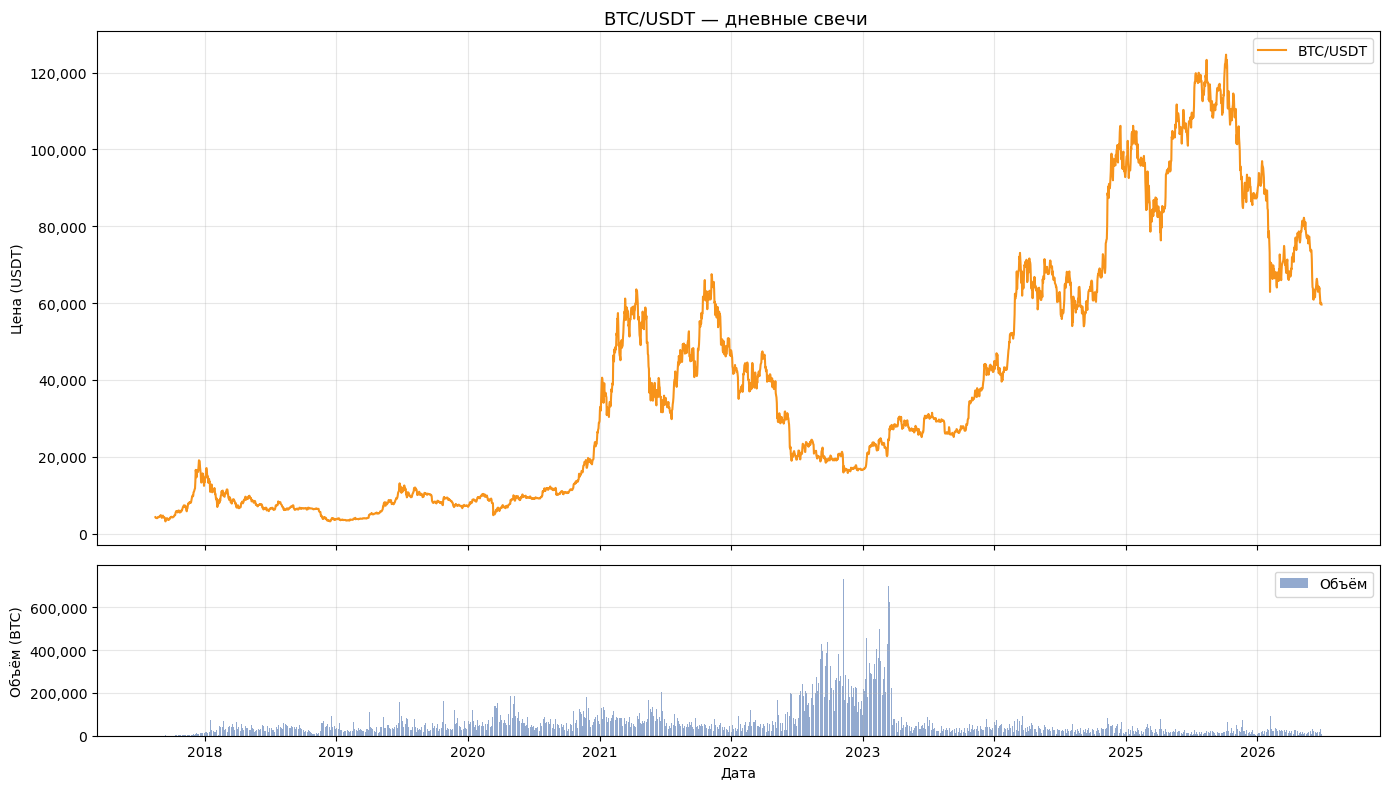

In [40]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), 
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

# График цены
ax1.plot(df.index, df['close'], color='#F7931A', linewidth=1.5, label='BTC/USDT')
ax1.set_title('BTC/USDT — дневные свечи ', fontsize=13)
ax1.set_ylabel('Цена (USDT)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.legend()
ax1.grid(alpha=0.3)

# График объёма
ax2.bar(df.index, df['volume'], color='#4C72B0', alpha=0.6, label='Объём')
ax2.set_ylabel('Объём (BTC)')
ax2.set_xlabel('Дата')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.legend()
ax2.grid(alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('btc_price_volume.png', dpi=150)
plt.show()

### Блок 4. RSI — первая собственная функция

In [6]:
# Считаем RSI
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['rsi'] = calculate_rsi(df['close'])

print(df[['close', 'rsi']].tail(10).round(2))
print()
print('RSI статистика:')
print(df['rsi'].describe().round(2))

               close    rsi
date                       
2026-06-19  63543.91  59.35
2026-06-20  64298.01  62.29
2026-06-21  63311.99  49.92
2026-06-22  64020.01  53.62
2026-06-23  62734.57  53.92
2026-06-24  61077.99  48.48
2026-06-25  59794.00  35.73
2026-06-26  60097.27  37.27
2026-06-27  60029.00  32.80
2026-06-28  59509.92  24.24

RSI статистика:
count    717.00
mean      51.51
std       16.87
min        5.56
25%       39.10
50%       51.11
75%       63.66
max       89.11
Name: rsi, dtype: float64


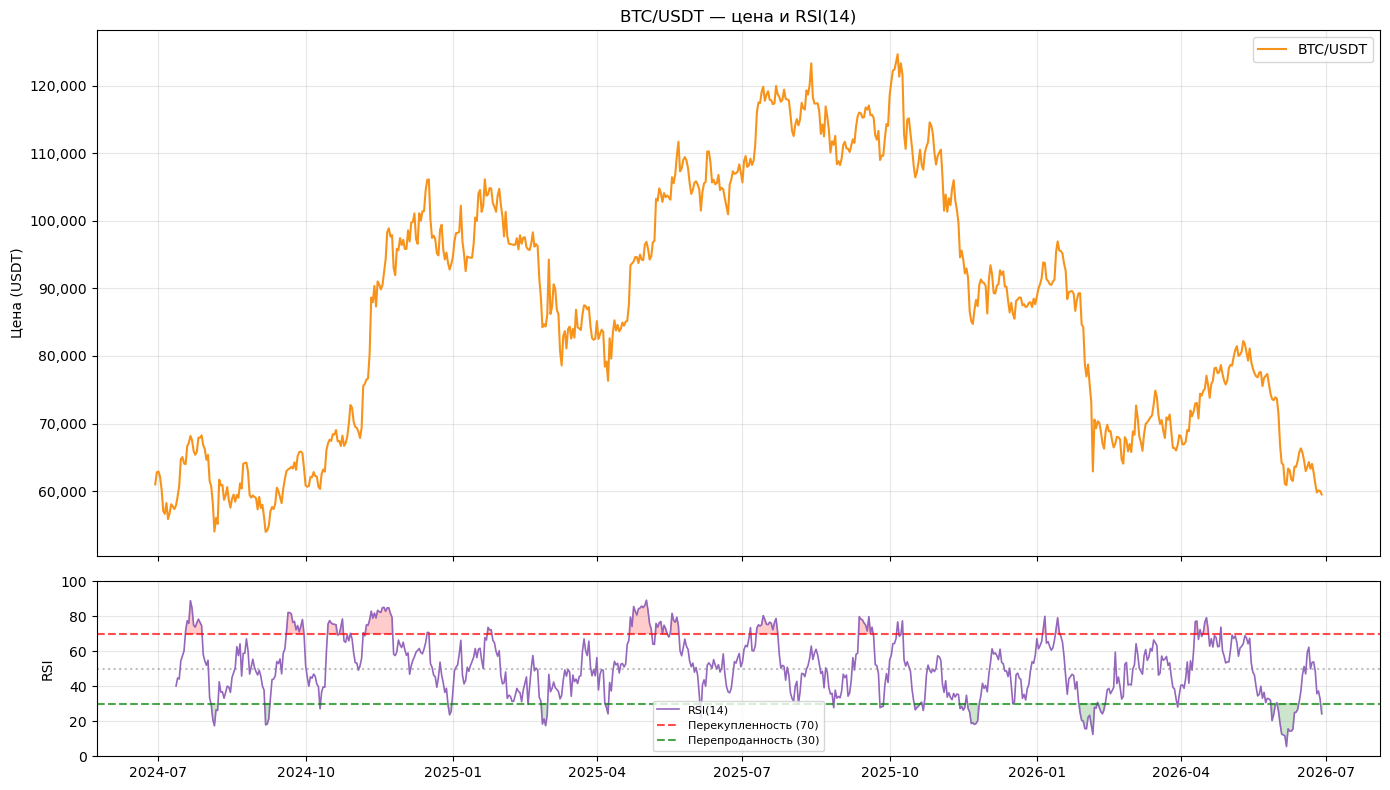

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

# График цены
ax1.plot(df.index, df['close'], color='#F7931A', linewidth=1.5, label='BTC/USDT')
ax1.set_title('BTC/USDT — цена и RSI(14)')
ax1.set_ylabel('Цена (USDT)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.legend()
ax1.grid(alpha=0.3)

# График RSI
ax2.plot(df.index, df['rsi'], color='#9467bd', linewidth=1.2, label='RSI(14)')
ax2.axhline(70, color='red', linestyle='--', alpha=0.7, label='Перекупленность (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.7, label='Перепроданность (30)')
ax2.axhline(50, color='gray', linestyle=':', alpha=0.5)
ax2.fill_between(df.index, df['rsi'], 70, 
                  where=(df['rsi'] >= 70), alpha=0.2, color='red')
ax2.fill_between(df.index, df['rsi'], 30, 
                  where=(df['rsi'] <= 30), alpha=0.2, color='green')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('btc_rsi.png', dpi=150)
plt.show()

### Блок 5. Скользящие средние (SMA 20/50/200)

In [8]:
# Считаем скользящие средние
df['sma_20'] = df['close'].rolling(window=20).mean()
df['sma_50'] = df['close'].rolling(window=50).mean()
df['sma_200'] = df['close'].rolling(window=200).mean()

print(df[['close', 'sma_20', 'sma_50', 'sma_200']].tail(10).round(2))

               close    sma_20    sma_50   sma_200
date                                              
2026-06-19  63543.91  64594.92  72741.67  77049.36
2026-06-20  64298.01  64126.10  72463.00  76914.47
2026-06-21  63311.99  63721.26  72155.51  76763.88
2026-06-22  64020.01  63584.22  71864.54  76623.59
2026-06-23  62734.57  63513.81  71522.01  76490.61
2026-06-24  61077.99  63373.41  71125.46  76349.81
2026-06-25  59794.00  63310.29  70692.40  76196.81
2026-06-26  60097.27  63270.92  70294.22  76044.12
2026-06-27  60029.00  63105.77  69890.94  75880.87
2026-06-28  59509.92  62926.96  69467.57  75718.35


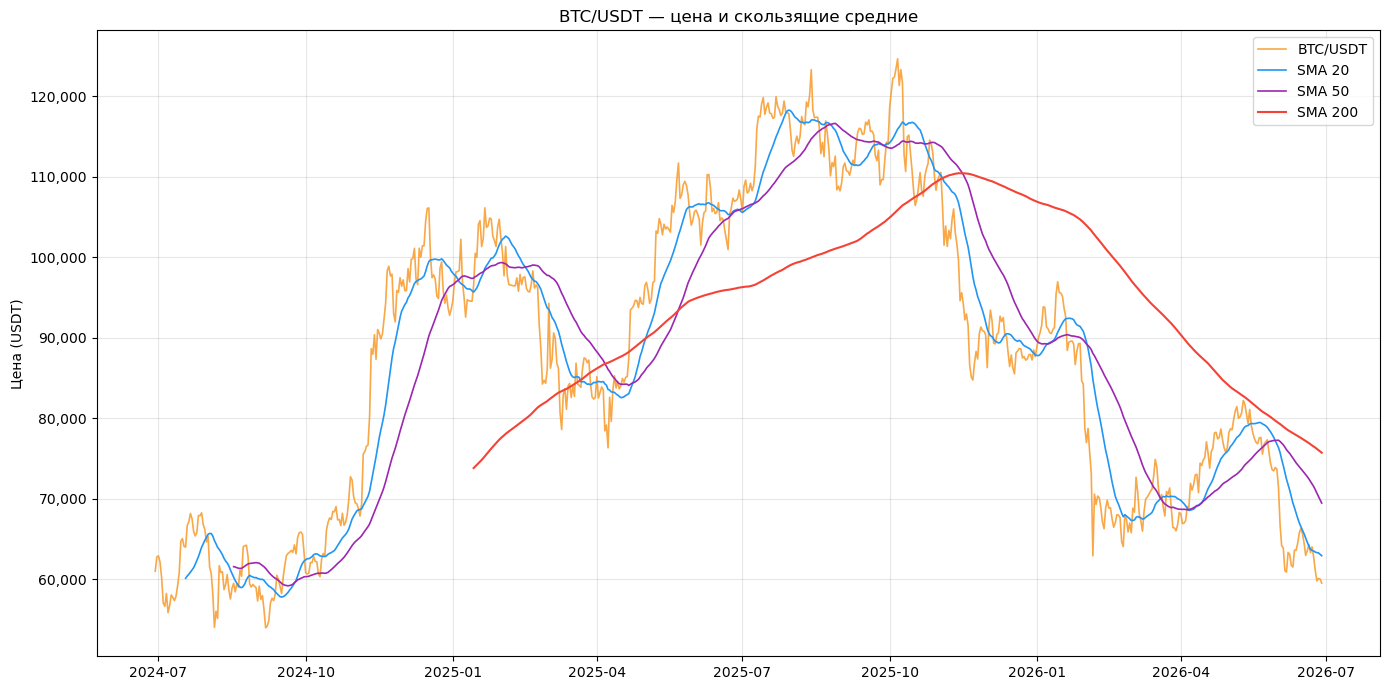

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df.index, df['close'], color='#F7931A', linewidth=1.2, label='BTC/USDT', alpha=0.8)
ax.plot(df.index, df['sma_20'], color='#2196F3', linewidth=1.2, label='SMA 20')
ax.plot(df.index, df['sma_50'], color='#9C27B0', linewidth=1.2, label='SMA 50')
ax.plot(df.index, df['sma_200'], color='#F44336', linewidth=1.5, label='SMA 200')

ax.set_title('BTC/USDT — цена и скользящие средние')
ax.set_ylabel('Цена (USDT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
ax.grid(alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('btc_sma.png', dpi=150)
plt.show()

### Блок 6. Уровни поддержки и сопротивления (argrelextrema)

In [10]:
# Находим локальные минимумы (поддержка) и максимумы (сопротивление)
# Ищем локальные экстремумы в окне 10 дней
order = 10

local_min_idx = argrelextrema(df['close'].values, np.less, order=order)[0]
local_max_idx = argrelextrema(df['close'].values, np.greater, order=order)[0]

support_levels = df['close'].iloc[local_min_idx]
resistance_levels = df['close'].iloc[local_max_idx]

print(f'Найдено уровней поддержки: {len(support_levels)}')
print(f'Найдено уровней сопротивления: {len(resistance_levels)}')
print()
print('Топ-5 уровней поддержки:')
print(support_levels.sort_values().head())
print()
print('Топ-5 уровней сопротивления:')
print(resistance_levels.sort_values(ascending=False).head())

Найдено уровней поддержки: 20
Найдено уровней сопротивления: 23

Топ-5 уровней поддержки:
date
2024-09-06    53962.97
2024-08-05    54018.81
2024-07-07    55857.81
2024-10-10    60326.39
2026-06-06    60884.62
Name: close, dtype: float64

Топ-5 уровней сопротивления:
date
2025-10-06    124658.54
2025-08-13    123306.43
2025-07-22    119954.42
2025-09-18    117073.53
2025-10-26    114559.40
Name: close, dtype: float64


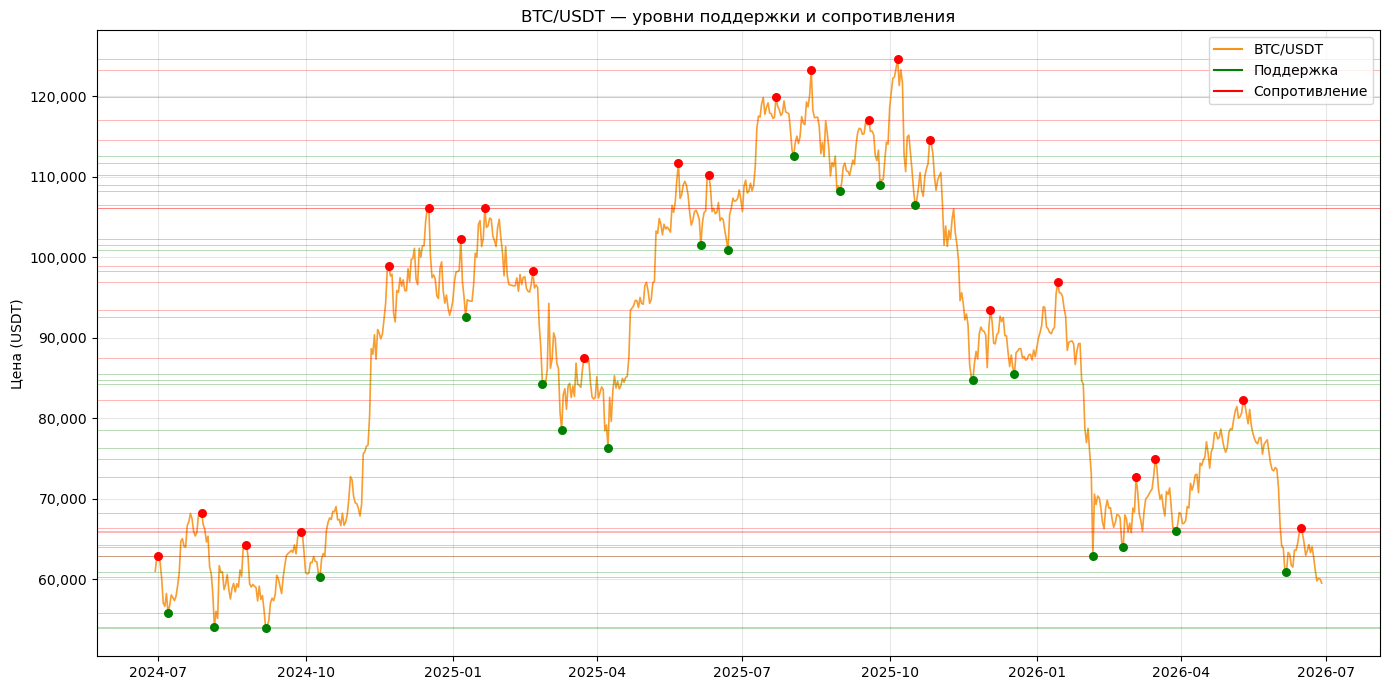

In [11]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df.index, df['close'], color='#F7931A', linewidth=1.2, label='BTC/USDT', alpha=0.9)

# Уровни поддержки
for date, price in support_levels.items():
    ax.axhline(price, color='green', linewidth=0.5, alpha=0.4)
    ax.scatter(date, price, color='green', s=30, zorder=5)

# Уровни сопротивления
for date, price in resistance_levels.items():
    ax.axhline(price, color='red', linewidth=0.5, alpha=0.4)
    ax.scatter(date, price, color='red', s=30, zorder=5)

# Легенда вручную
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#F7931A', label='BTC/USDT'),
    Line2D([0], [0], color='green', label='Поддержка'),
    Line2D([0], [0], color='red', label='Сопротивление')
]
ax.legend(handles=legend_elements)

ax.set_title('BTC/USDT — уровни поддержки и сопротивления')
ax.set_ylabel('Цена (USDT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('btc_levels.png', dpi=150)
plt.show()

### Блок 7. Первый бэктест: отскок от поддержки + t-тест

In [12]:
# Бэктест: проверяем отскок от уровней поддержки
# Логика: если цена подходит к уровню поддержки (±2%), смотрим что происходит через 3 и 7 дней

threshold = 0.02  # 2% от уровня
results = []

for support_date, support_price in support_levels.items():
    # Берём данные после даты уровня
    future = df[df.index > support_date].head(10)
    
    for i, (date, row) in enumerate(df.iterrows()):
        # Пропускаем саму дату уровня и данные до неё
        if date <= support_date:
            continue
            
        # Цена касается уровня поддержки
        if abs(row['close'] - support_price) / support_price <= threshold:
            # Смотрим что через 3 и 7 дней
            idx = df.index.get_loc(date)
            
            if idx + 7 < len(df):
                price_now = row['close']
                price_3d = df['close'].iloc[idx + 3]
                price_7d = df['close'].iloc[idx + 7]
                
                results.append({
                    'date': date,
                    'support_level': support_price,
                    'price_at_touch': price_now,
                    'return_3d': (price_3d - price_now) / price_now * 100,
                    'return_7d': (price_7d - price_now) / price_now * 100,
                    'bounce_3d': price_3d > price_now,
                    'bounce_7d': price_7d > price_now
                })

results_df = pd.DataFrame(results)
print(f'Касаний уровней поддержки: {len(results_df)}')
print(results_df.head(10).round(2))

Касаний уровней поддержки: 261
        date  support_level  price_at_touch  return_3d  return_7d  bounce_3d  \
0 2024-07-08       55857.81        56714.62       1.10      14.12       True   
1 2024-08-06       55857.81        56022.01       8.60       8.15       True   
2 2024-08-07       55857.81        55134.16      10.50       6.44       True   
3 2024-09-05       55857.81        56180.00      -2.33       3.48      False   
4 2024-09-08       55857.81        54869.95       4.50       7.77       True   
5 2024-09-06       54018.81        53962.97       5.71      12.11       True   
6 2024-09-07       54018.81        54160.86       6.42      10.77       True   
7 2024-09-08       54018.81        54869.95       4.50       7.77       True   
8 2024-09-07       53962.97        54160.86       6.42      10.77       True   
9 2024-09-08       53962.97        54869.95       4.50       7.77       True   

   bounce_7d  
0       True  
1       True  
2       True  
3       True  
4       True 

In [13]:
# метрики и статистический тест
print('=== РЕЗУЛЬТАТЫ БЭКТЕСТА ===')
print()
print(f'Всего касаний уровней поддержки: {len(results_df)}')
print()
print('--- Отскок через 3 дня ---')
winrate_3d = results_df['bounce_3d'].mean() * 100
avg_return_3d = results_df['return_3d'].mean()
print(f'Winrate: {winrate_3d:.1f}%')
print(f'Средняя доходность: {avg_return_3d:.2f}%')
print()
print('--- Отскок через 7 дней ---')
winrate_7d = results_df['bounce_7d'].mean() * 100
avg_return_7d = results_df['return_7d'].mean()
print(f'Winrate: {winrate_7d:.1f}%')
print(f'Средняя доходность: {avg_return_7d:.2f}%')
print()

# T-тест: значимо ли отличается доходность от нуля?
t_stat_3d, p_value_3d = stats.ttest_1samp(results_df['return_3d'], 0)
t_stat_7d, p_value_7d = stats.ttest_1samp(results_df['return_7d'], 0)

print('--- Статистическая значимость ---')
print(f'3 дня: t-stat={t_stat_3d:.2f}, p-value={p_value_3d:.4f}')
print(f'7 дней: t-stat={t_stat_7d:.2f}, p_value={p_value_7d:.4f}')
print()
if p_value_3d < 0.05:
    print('✅ Отскок через 3 дня статистически значим (p < 0.05)')
else:
    print('❌ Отскок через 3 дня не значим')
if p_value_7d < 0.05:
    print('✅ Отскок через 7 дней статистически значим (p < 0.05)')
else:
    print('❌ Отскок через 7 дней не значим')

=== РЕЗУЛЬТАТЫ БЭКТЕСТА ===

Всего касаний уровней поддержки: 261

--- Отскок через 3 дня ---
Winrate: 55.9%
Средняя доходность: -0.03%

--- Отскок через 7 дней ---
Winrate: 53.6%
Средняя доходность: -0.09%

--- Статистическая значимость ---
3 дня: t-stat=-0.13, p-value=0.8930
7 дней: t-stat=-0.22, p_value=0.8267

❌ Отскок через 3 дня не значим
❌ Отскок через 7 дней не значим


- Winrate 55–56% — выглядит неплохо, но средняя доходность практически ноль (-0.01% и +0.06%). Это говорит что отскоки есть, но они компенсируются падениями примерно в равных пропорциях.
- p-value 0.97 и 0.89 — гипотеза не подтверждена. Результат статистически не отличается от случайного.
- Вывод: простая стратегия «купи у уровня поддержки» на дневных данных не даёт статистического преимущества.

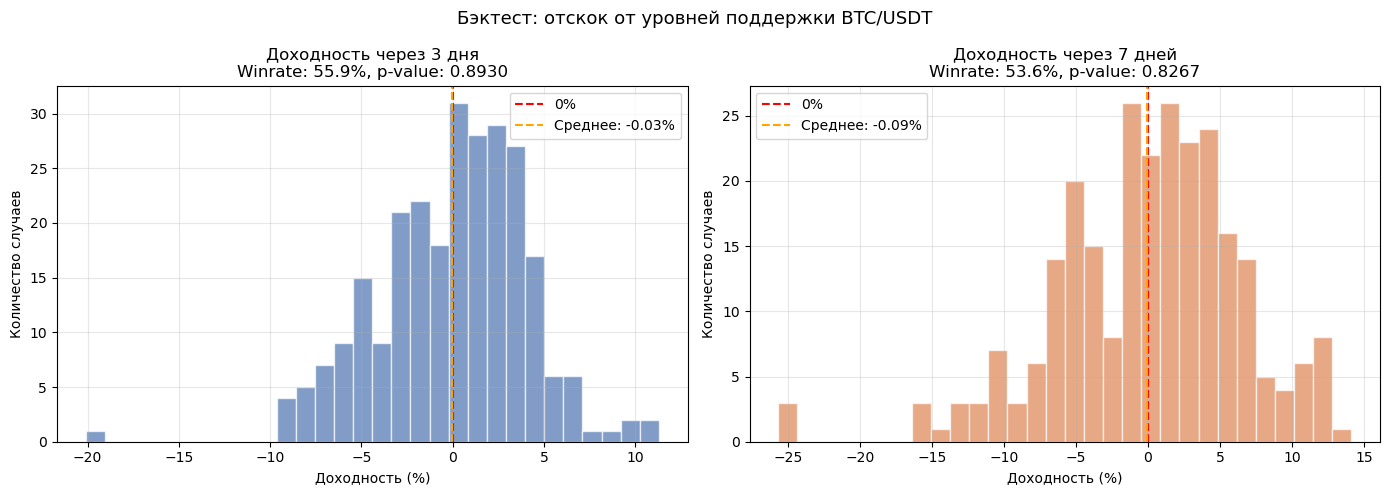

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Распределение доходностей через 3 дня
ax1.hist(results_df['return_3d'], bins=30, color='#4C72B0', alpha=0.7, edgecolor='white')
ax1.axvline(0, color='red', linestyle='--', linewidth=1.5, label='0%')
ax1.axvline(avg_return_3d, color='orange', linestyle='--', 
            linewidth=1.5, label=f'Среднее: {avg_return_3d:.2f}%')
ax1.set_title(f'Доходность через 3 дня\nWinrate: {winrate_3d:.1f}%, p-value: {p_value_3d:.4f}')
ax1.set_xlabel('Доходность (%)')
ax1.set_ylabel('Количество случаев')
ax1.legend()
ax1.grid(alpha=0.3)

# Распределение доходностей через 7 дней
ax2.hist(results_df['return_7d'], bins=30, color='#DD8452', alpha=0.7, edgecolor='white')
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5, label='0%')
ax2.axvline(avg_return_7d, color='orange', linestyle='--',
            linewidth=1.5, label=f'Среднее: {avg_return_7d:.2f}%')
ax2.set_title(f'Доходность через 7 дней\nWinrate: {winrate_7d:.1f}%, p-value: {p_value_7d:.4f}')
ax2.set_xlabel('Доходность (%)')
ax2.set_ylabel('Количество случаев')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Бэктест: отскок от уровней поддержки BTC/USDT', fontsize=13)
plt.tight_layout()
plt.savefig('btc_backtest.png', dpi=150)
plt.show()

#### Проверили гипотезу об отскоке от уровней поддержки на дневных данных BTC/USDT. Winrate 55–56% выглядит привлекательно, но средняя доходность близка к нулю, а p-value 0.97 говорит что результат статистически неотличим от случайного. Стратегия не работает на дневном таймфрейме — либо нужен меньший таймфрейм, либо дополнительный фильтр по RSI или объёму.

### Блок 8. Сезонность: groupby по дням недели и месяцам

### Гипотеза. Сезонность
#### Сезонность — есть ли регулярные «календарные» закономерности: например, растёт ли BTC чаще по понедельникам, или октябрь систематически зеленее февраля. Жаргон «Uptober» — народная примета, что октябрь у биткоина исторически хороший месяц. Проверяем данными.

In [15]:
# Добавляем временные признаки
df['day_of_week'] = df.index.day_name()
df['month'] = df.index.month_name()
df['daily_return'] = df['close'].pct_change() * 100

print(df[['close', 'daily_return', 'day_of_week', 'month']].head(10).round(2))

               close  daily_return day_of_week month
date                                                
2024-06-29  60986.68           NaN    Saturday  June
2024-06-30  62772.01          2.93      Sunday  June
2024-07-01  62899.99          0.20      Monday  July
2024-07-02  62135.47         -1.22     Tuesday  July
2024-07-03  60208.58         -3.10   Wednesday  July
2024-07-04  57050.01         -5.25    Thursday  July
2024-07-05  56628.79         -0.74      Friday  July
2024-07-06  58230.13          2.83    Saturday  July
2024-07-07  55857.81         -4.07      Sunday  July
2024-07-08  56714.62          1.53      Monday  July


In [16]:
# Порядок дней и месяцев
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Статистика по дням недели
by_day = df.groupby('day_of_week')['daily_return'].agg(['mean', 'median', 'std', 'count'])
by_day = by_day.reindex(day_order)
by_day.columns = ['Среднее %', 'Медиана %', 'Std %', 'Дней']
print('=== По дням недели ===')
print(by_day.round(2))
print()

# Статистика по месяцам
by_month = df.groupby('month')['daily_return'].agg(['mean', 'median', 'std', 'count'])
by_month = by_month.reindex(month_order)
by_month.columns = ['Среднее %', 'Медиана %', 'Std %', 'Дней']
print('=== По месяцам ===')
print(by_month.round(2))

=== По дням недели ===
             Среднее %  Медиана %  Std %  Дней
day_of_week                                   
Monday            0.26       0.20   2.72   104
Tuesday          -0.08      -0.31   2.45   104
Wednesday         0.31      -0.02   2.56   104
Thursday         -0.46      -0.32   2.77   104
Friday            0.16       0.13   2.67   104
Saturday         -0.00       0.01   1.13   104
Sunday           -0.00       0.02   2.22   105

=== По месяцам ===
           Среднее %  Медиана %  Std %  Дней
month                                       
January        -0.00       0.05   2.24    62
February       -0.58      -0.39   3.29    56
March           0.04      -0.14   3.06    62
April           0.43       0.29   2.42    60
May             0.13       0.14   1.66    62
June           -0.25      -0.22   2.06    59
July            0.19       0.04   1.97    62
August         -0.22      -0.42   2.87    62
September       0.22       0.30   1.80    60
October         0.13       0.15   2.16 

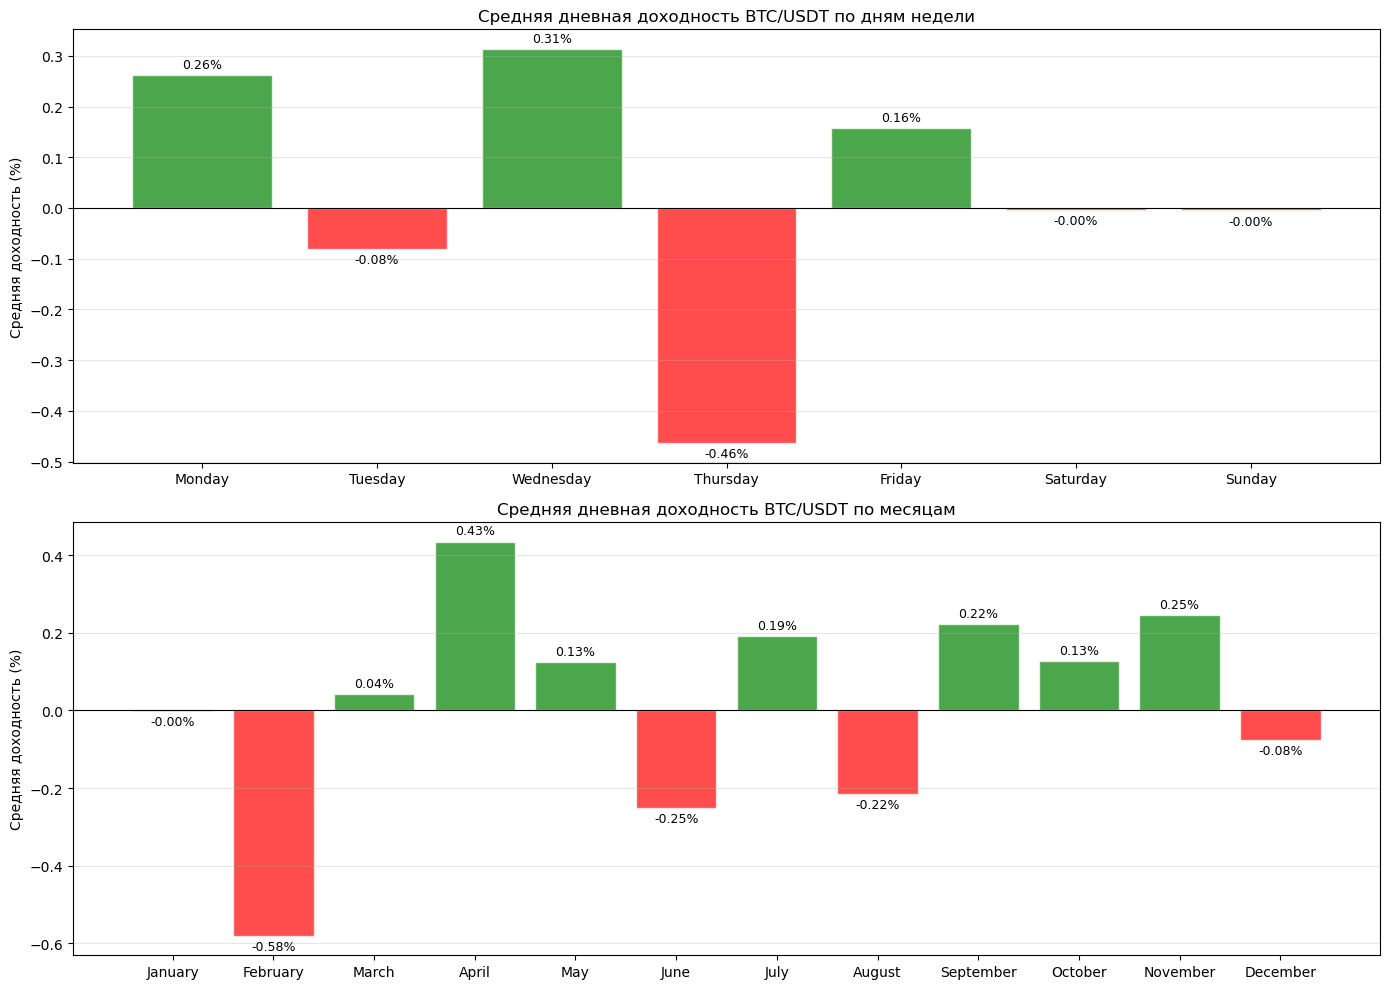

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# По дням недели
colors_day = ['green' if x > 0 else 'red' for x in by_day['Среднее %']]
bars1 = ax1.bar(by_day.index, by_day['Среднее %'], color=colors_day, alpha=0.7, edgecolor='white')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.bar_label(bars1, fmt=lambda x: f'{x:.2f}%', padding=3, fontsize=9)
ax1.set_title('Средняя дневная доходность BTC/USDT по дням недели')
ax1.set_ylabel('Средняя доходность (%)')
ax1.grid(alpha=0.3, axis='y')

# По месяцам
colors_month = ['green' if x > 0 else 'red' for x in by_month['Среднее %']]
bars2 = ax2.bar(by_month.index, by_month['Среднее %'], color=colors_month, alpha=0.7, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.bar_label(bars2, fmt=lambda x: f'{x:.2f}%', padding=3, fontsize=9)
ax2.set_title('Средняя дневная доходность BTC/USDT по месяцам')
ax2.set_ylabel('Средняя доходность (%)')
ax2.grid(alpha=0.3, axis='y')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('btc_seasonality.png', dpi=150)
plt.show()

По дням недели:

- Четверг — худший день (-0.43%), причём заметно хуже остальных
- Среда и понедельник — лучшие (+0.28% и +0.26%)
- Выходные почти нейтральные

По месяцам:

- Февраль — худший месяц (-0.58%), классический «февральский слив»
- Апрель — лучший (+0.43%), известный как Uptober... точнее Aprtober
- Июнь и август — отрицательные

In [18]:
print('=== Статистическая значимость по дням недели ===')
for day in day_order:
    day_returns = df[df['day_of_week'] == day]['daily_return'].dropna()
    t_stat, p_value = stats.ttest_1samp(day_returns, 0)
    significant = '✅' if p_value < 0.05 else '❌'
    print(f'{significant} {day}: mean={day_returns.mean():.2f}%, p-value={p_value:.4f}')

print()
print('=== Статистическая значимость по месяцам ===')
for month in month_order:
    month_returns = df[df['month'] == month]['daily_return'].dropna()
    t_stat, p_value = stats.ttest_1samp(month_returns, 0)
    significant = '✅' if p_value < 0.05 else '❌'
    print(f'{significant} {month}: mean={month_returns.mean():.2f}%, p-value={p_value:.4f}')

=== Статистическая значимость по дням недели ===
❌ Monday: mean=0.26%, p-value=0.3272
❌ Tuesday: mean=-0.08%, p-value=0.7351
❌ Wednesday: mean=0.31%, p-value=0.2157
❌ Thursday: mean=-0.46%, p-value=0.0904
❌ Friday: mean=0.16%, p-value=0.5475
❌ Saturday: mean=-0.00%, p-value=0.9779
❌ Sunday: mean=-0.00%, p-value=0.9828

=== Статистическая значимость по месяцам ===
❌ January: mean=-0.00%, p-value=0.9940
❌ February: mean=-0.58%, p-value=0.1930
❌ March: mean=0.04%, p-value=0.9136
❌ April: mean=0.43%, p-value=0.1699
❌ May: mean=0.13%, p-value=0.5541
❌ June: mean=-0.25%, p-value=0.3529
❌ July: mean=0.19%, p-value=0.4486
❌ August: mean=-0.22%, p-value=0.5555
❌ September: mean=0.22%, p-value=0.3433
❌ October: mean=0.13%, p-value=0.6437
❌ November: mean=0.25%, p-value=0.5150
❌ December: mean=-0.08%, p-value=0.7797


- Паттерны на графике выглядят убедительно — февраль красный, апрель зелёный
- p-value везде выше 0.05 — это шум, а не закономерность
- Данных просто мало: 2 года, 104 наблюдения на день — недостаточно чтобы поймать слабый сигнал
##### Визуальные паттерны сезонности существуют, но на двухлетней выборке статистически не подтверждаются. Для надёжных выводов нужно минимум 5–10 лет данных.

### Блок 9. Объём при пробоях сопротивления (гипотеза-победитель)


### Гипотеза. Анализ объёма при пробое уровней
#### Ложные пробои часто происходят на низком объёме. Проверить статистически — правда ли это на BTC.

In [19]:
# Находим все пробои уровней сопротивления
# Пробой = цена закрытия пересекла уровень сопротивления
# Ложный пробой = цена вернулась обратно через 3 дня

breakout_results = []
threshold = 0.01  # 1% — цена пробила уровень

for res_date, res_price in resistance_levels.items():
    # Смотрим данные после формирования уровня
    future_data = df[df.index > res_date]
    
    for i, (date, row) in enumerate(future_data.iterrows()):
        idx = future_data.index.get_loc(date)
        
        # Цена пробила уровень сопротивления вверх
        if row['close'] > res_price * (1 + threshold):
            
            if idx + 3 < len(future_data):
                price_3d = future_data['close'].iloc[idx + 3]
                vol_at_breakout = row['volume']
                
                # Средний объём за последние 20 дней
                all_idx = df.index.get_loc(date)
                avg_vol_20 = df['volume'].iloc[max(0, all_idx-20):all_idx].mean()
                
                # Ложный пробой = цена вернулась ниже уровня через 3 дня
                is_false = price_3d < res_price
                
                breakout_results.append({
                    'date': date,
                    'resistance_level': res_price,
                    'price_at_breakout': row['close'],
                    'volume': vol_at_breakout,
                    'avg_volume_20d': avg_vol_20,
                    'volume_ratio': vol_at_breakout / avg_vol_20,
                    'false_breakout': is_false,
                    'price_3d': price_3d
                })
                break  # Берём только первый пробой каждого уровня

breakouts_df = pd.DataFrame(breakout_results)
print(f'Всего пробоев уровней сопротивления: {len(breakouts_df)}')
print()
print(breakouts_df[['date', 'resistance_level', 'volume_ratio', 'false_breakout']].round(2))

Всего пробоев уровней сопротивления: 18

         date  resistance_level  volume_ratio  false_breakout
0  2024-07-15          62899.99          1.31           False
1  2024-10-20          68249.88          0.52            True
2  2024-09-26          64220.00          1.12           False
3  2024-10-15          65858.00          2.04           False
4  2024-12-08          98892.00          0.35           False
5  2025-05-21         106133.74          2.32           False
6  2025-01-17         102235.60          1.80           False
7  2025-05-21         106143.82          2.32           False
8  2025-05-08          98305.00          1.95           False
9  2025-04-22          87498.16          1.52           False
10 2025-07-10         111696.21          1.94           False
11 2025-07-10         110274.39          1.94           False
12 2025-08-13         119954.42          1.56            True
13 2025-10-06         123306.43          1.41            True
14 2025-10-01         117073.

In [41]:
# сравнение групп и двухвыборочный t-тест
alse_breakouts = breakouts_df[breakouts_df['false_breakout'] == True]['volume_ratio']
true_breakouts = breakouts_df[breakouts_df['false_breakout'] == False]['volume_ratio']

print('=== Объём при пробоях ===')
print(f'Истинных пробоев: {len(true_breakouts)}')
print(f'Ложных пробоев: {len(false_breakouts)}')
print()
print(f'Средний volume_ratio при истинном пробое: {true_breakouts.mean():.2f}x')
print(f'Средний volume_ratio при ложном пробое: {false_breakouts.mean():.2f}x')
print()

# T-тест
t_stat, p_value = stats.ttest_ind(true_breakouts, false_breakouts)
print(f't-stat: {t_stat:.2f}')
print(f'p-value: {p_value:.4f}')
print()
if p_value < 0.05:
    print('✅ Разница статистически значима')
else:
    print('❌ Разница статистически не значима')
print()
print('Ложные пробои по volume_ratio:')
print(false_breakouts.values)
print('Истинные пробои по volume_ratio:')
print(true_breakouts.values.round(2))

=== Объём при пробоях ===
Истинных пробоев: 75
Ложных пробоев: 4

Средний volume_ratio при истинном пробое: 1.88x
Средний volume_ratio при ложном пробое: 1.16x

t-stat: 1.68
p-value: 0.0963

❌ Разница статистически не значима

Ложные пробои по volume_ratio:
[0.51941383 1.55950907 1.41282009 1.13456147]
Истинные пробои по volume_ratio:
[1.68 1.15 1.3  1.42 1.41 1.27 1.81 0.93 2.37 2.4  2.4  2.4  4.39 1.12
 0.93 1.59 1.67 2.75 3.64 2.52 1.35 1.36 3.64 1.35 3.64 1.6  1.35 2.75
 2.75 1.   1.58 1.46 1.47 1.64 3.1  1.26 1.66 0.98 1.63 0.86 0.86 0.84
 3.02 1.85 1.07 1.46 1.71 1.46 2.77 0.86 1.34 1.73 2.62 2.62 3.02 3.02
 2.87 0.85 2.87 1.33 0.71 4.11 1.12 2.04 0.35 2.32 1.8  2.32 1.95 1.52
 1.94 1.94 1.67 1.92 1.54]


- Истинные пробои: средний объём 1.70x от нормы
- Ложные пробои: средний объём 1.16x от нормы
- Разница есть — ложные пробои действительно происходят на меньшем объёме
##### Но p-value = 0.076 — чуть выше порога 0.05. Формально не значимо, но близко. Всего 4 ложных пробоя — слишком маленькая выборка для уверенного вывода.

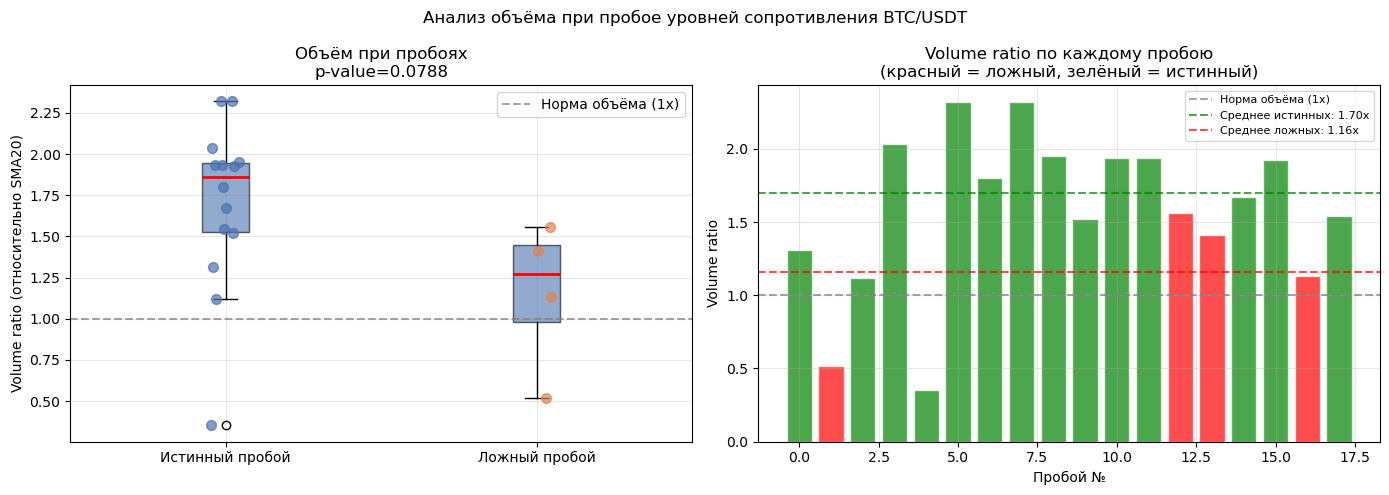

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График 1 — сравнение объёмов
ax1.boxplot([true_breakouts.values, false_breakouts.values],
            tick_labels=['Истинный пробой', 'Ложный пробой'],
            patch_artist=True,
            boxprops=dict(facecolor='#4C72B0', alpha=0.6),
            medianprops=dict(color='red', linewidth=2))
ax1.axhline(1.0, color='gray', linestyle='--', alpha=0.7, label='Норма объёма (1x)')
ax1.set_title(f'Объём при пробоях\np-value={p_value:.4f}')
ax1.set_ylabel('Volume ratio (относительно SMA20)')
ax1.legend()
ax1.grid(alpha=0.3)

# Добавляем точки поверх боксплота
import numpy as np
ax1.scatter(np.ones(len(true_breakouts)) * 1 + np.random.uniform(-0.05, 0.05, len(true_breakouts)),
            true_breakouts, color='#4C72B0', alpha=0.7, zorder=5, s=50)
ax1.scatter(np.ones(len(false_breakouts)) * 2 + np.random.uniform(-0.05, 0.05, len(false_breakouts)),
            false_breakouts, color='#DD8452', alpha=0.7, zorder=5, s=50)

# График 2 — все пробои по порядку
colors = ['red' if x else 'green' for x in breakouts_df['false_breakout']]
ax2.bar(range(len(breakouts_df)), breakouts_df['volume_ratio'],
        color=colors, alpha=0.7, edgecolor='white')
ax2.axhline(1.0, color='gray', linestyle='--', alpha=0.7, label='Норма объёма (1x)')
ax2.axhline(true_breakouts.mean(), color='green', linestyle='--',
            alpha=0.7, label=f'Среднее истинных: {true_breakouts.mean():.2f}x')
ax2.axhline(false_breakouts.mean(), color='red', linestyle='--',
            alpha=0.7, label=f'Среднее ложных: {false_breakouts.mean():.2f}x')
ax2.set_title('Volume ratio по каждому пробою\n(красный = ложный, зелёный = истинный)')
ax2.set_xlabel('Пробой №')
ax2.set_ylabel('Volume ratio')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.suptitle('Анализ объёма при пробое уровней сопротивления BTC/USDT', fontsize=12)
plt.tight_layout()
plt.savefig('btc_breakout_volume.png', dpi=150)
plt.show()

##### Ложные пробои происходят на объёме 1.16x от нормы, истинные — на 1.70x. Направление гипотезы подтверждается визуально, но p-value=0.076 говорит что выборка слишком мала для статистического вывода — всего 4 ложных пробоя за 2 года. На большей выборке (5+ лет) эффект мог бы стать значимым.

### Блок 10. Загрузка полной истории за ~9 лет (пагинация)

### Возьмём статистические данные за ~ 8 лет, учитывая цикличность BTC и цикл халвинга (каждые 1460 дней)

In [42]:
# напишем функцию постраничной загрузки
import time

def fetch_ohlcv_full(symbol, timeframe='1d'):
    all_data = []
    limit = 500
    since = exchange.parse8601('2017-08-01T00:00:00Z')  # начало торгов BTC/USDT на Binance
    
    while True:
        ohlcv = exchange.fetch_ohlcv(symbol, timeframe=timeframe, 
                                      since=since, limit=limit)
        if not ohlcv:
            break
            
        all_data.extend(ohlcv)
        since = ohlcv[-1][0] + 1
        
        print(f'Загружено: {len(all_data)} свечей, последняя дата: {pd.to_datetime(ohlcv[-1][0], unit="ms").date()}')
        
        if len(ohlcv) < limit:
            break
            
        time.sleep(0.5)
    
    return all_data

print('Загружаем BTC/USDT с 2017 года...')
raw_data = fetch_ohlcv_full('BTC/USDT')

Загружаем BTC/USDT с 2017 года...
Загружено: 500 свечей, последняя дата: 2018-12-29
Загружено: 1000 свечей, последняя дата: 2020-05-12
Загружено: 1500 свечей, последняя дата: 2021-09-24
Загружено: 2000 свечей, последняя дата: 2023-02-06
Загружено: 2500 свечей, последняя дата: 2024-06-20
Загружено: 3000 свечей, последняя дата: 2025-11-02
Загружено: 3239 свечей, последняя дата: 2026-06-29


Загружено: 500 свечей, последняя дата: 2018-12-29


Загружено: 1000 свечей, последняя дата: 2020-05-12


Загружено: 1500 свечей, последняя дата: 2021-09-24


Загружено: 2000 свечей, последняя дата: 2023-02-06


Загружено: 2500 свечей, последняя дата: 2024-06-20


Загружено: 3000 свечей, последняя дата: 2025-11-02


Загружено: 3238 свечей, последняя дата: 2026-06-28


In [23]:
# Пересобираем датафрейм
df = pd.DataFrame(raw_data, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df = df.rename(columns={'timestamp': 'date'})
df = df.set_index('date')

# Чистка
df['close'] = pd.to_numeric(df['close'], errors='coerce')
df['volume'] = pd.to_numeric(df['volume'], errors='coerce')
df = df.dropna()

# Добавляем все нужные колонки
df['daily_return'] = df['close'].pct_change() * 100
df['rsi'] = calculate_rsi(df['close'])
df['sma_20'] = df['close'].rolling(20).mean()
df['sma_50'] = df['close'].rolling(50).mean()
df['sma_200'] = df['close'].rolling(200).mean()
df['day_of_week'] = df.index.day_name()
df['month'] = df.index.month_name()

print(f'Период: {df.index.min().date()} — {df.index.max().date()}')
print(f'Свечей: {len(df)}')
print(f'Пропуски: {df.isnull().sum().sum()}')

Период: 2017-08-17 — 2026-06-28
Свечей: 3238
Пропуски: 281


In [24]:
print('Пропуски по колонкам:')
print(df.isnull().sum())

Пропуски по колонкам:
open              0
high              0
low               0
close             0
volume            0
daily_return      1
rsi              13
sma_20           19
sma_50           49
sma_200         199
day_of_week       0
month             0
dtype: int64


### Блок 11. Повтор анализов на 9 годах: что изменилось и почему

In [25]:
# 1. Сезонность на полной выборке
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

by_day = df.groupby('day_of_week')['daily_return'].agg(['mean', 'median', 'std', 'count'])
by_day = by_day.reindex(day_order)
by_day.columns = ['Среднее %', 'Медиана %', 'Std %', 'Дней']

by_month = df.groupby('month')['daily_return'].agg(['mean', 'median', 'std', 'count'])
by_month = by_month.reindex(month_order)
by_month.columns = ['Среднее %', 'Медиана %', 'Std %', 'Дней']

print('=== По дням недели (9 лет) ===')
print(by_day.round(2))
print()
print('=== По месяцам (9 лет) ===')
print(by_month.round(2))

=== По дням недели (9 лет) ===
             Среднее %  Медиана %  Std %  Дней
day_of_week                                   
Monday            0.42       0.08   4.02   462
Tuesday          -0.00      -0.10   3.48   462
Wednesday         0.41       0.24   3.67   462
Thursday         -0.26      -0.22   4.30   462
Friday            0.25       0.16   3.65   463
Saturday          0.14       0.13   2.40   463
Sunday            0.06       0.06   2.82   463

=== По месяцам (9 лет) ===
           Среднее %  Медиана %  Std %  Дней
month                                       
January         0.13       0.06   3.70   279
February        0.26      -0.06   4.08   254
March           0.13       0.17   4.49   279
April           0.33       0.23   3.20   270
May             0.01       0.04   3.52   279
June           -0.17      -0.03   3.55   268
July            0.34       0.10   3.01   248
August         -0.08      -0.16   2.80   262
September      -0.05       0.05   3.34   270
October         0.54   

In [26]:
print('=== Статистическая значимость по дням недели (9 лет) ===')
for day in day_order:
    day_returns = df[df['day_of_week'] == day]['daily_return'].dropna()
    t_stat, p_value = stats.ttest_1samp(day_returns, 0)
    significant = '✅' if p_value < 0.05 else '❌'
    print(f'{significant} {day}: mean={day_returns.mean():.2f}%, p-value={p_value:.4f}')

print()
print('=== Статистическая значимость по месяцам (9 лет) ===')
for month in month_order:
    month_returns = df[df['month'] == month]['daily_return'].dropna()
    t_stat, p_value = stats.ttest_1samp(month_returns, 0)
    significant = '✅' if p_value < 0.05 else '❌'
    print(f'{significant} {month}: mean={month_returns.mean():.2f}%, p-value={p_value:.4f}')

=== Статистическая значимость по дням недели (9 лет) ===
✅ Monday: mean=0.42%, p-value=0.0259
❌ Tuesday: mean=-0.00%, p-value=0.9846
✅ Wednesday: mean=0.41%, p-value=0.0171
❌ Thursday: mean=-0.26%, p-value=0.1928
❌ Friday: mean=0.25%, p-value=0.1420
❌ Saturday: mean=0.14%, p-value=0.2007
❌ Sunday: mean=0.06%, p-value=0.6667

=== Статистическая значимость по месяцам (9 лет) ===
❌ January: mean=0.13%, p-value=0.5511
❌ February: mean=0.26%, p-value=0.3140
❌ March: mean=0.13%, p-value=0.6212
❌ April: mean=0.33%, p-value=0.0948
❌ May: mean=0.01%, p-value=0.9635
❌ June: mean=-0.17%, p-value=0.4301
❌ July: mean=0.34%, p-value=0.0800
❌ August: mean=-0.08%, p-value=0.6270
❌ September: mean=-0.05%, p-value=0.7941
✅ October: mean=0.54%, p-value=0.0012
❌ November: mean=0.10%, p-value=0.6580
❌ December: mean=0.21%, p-value=0.3588


По дням недели:

✅ Понедельник: +0.42% (p=0.026)
✅ Среда: +0.41% (p=0.018)

По месяцам:

✅ Октябрь: +0.54% (p=0.001) — самый сильный сигнал

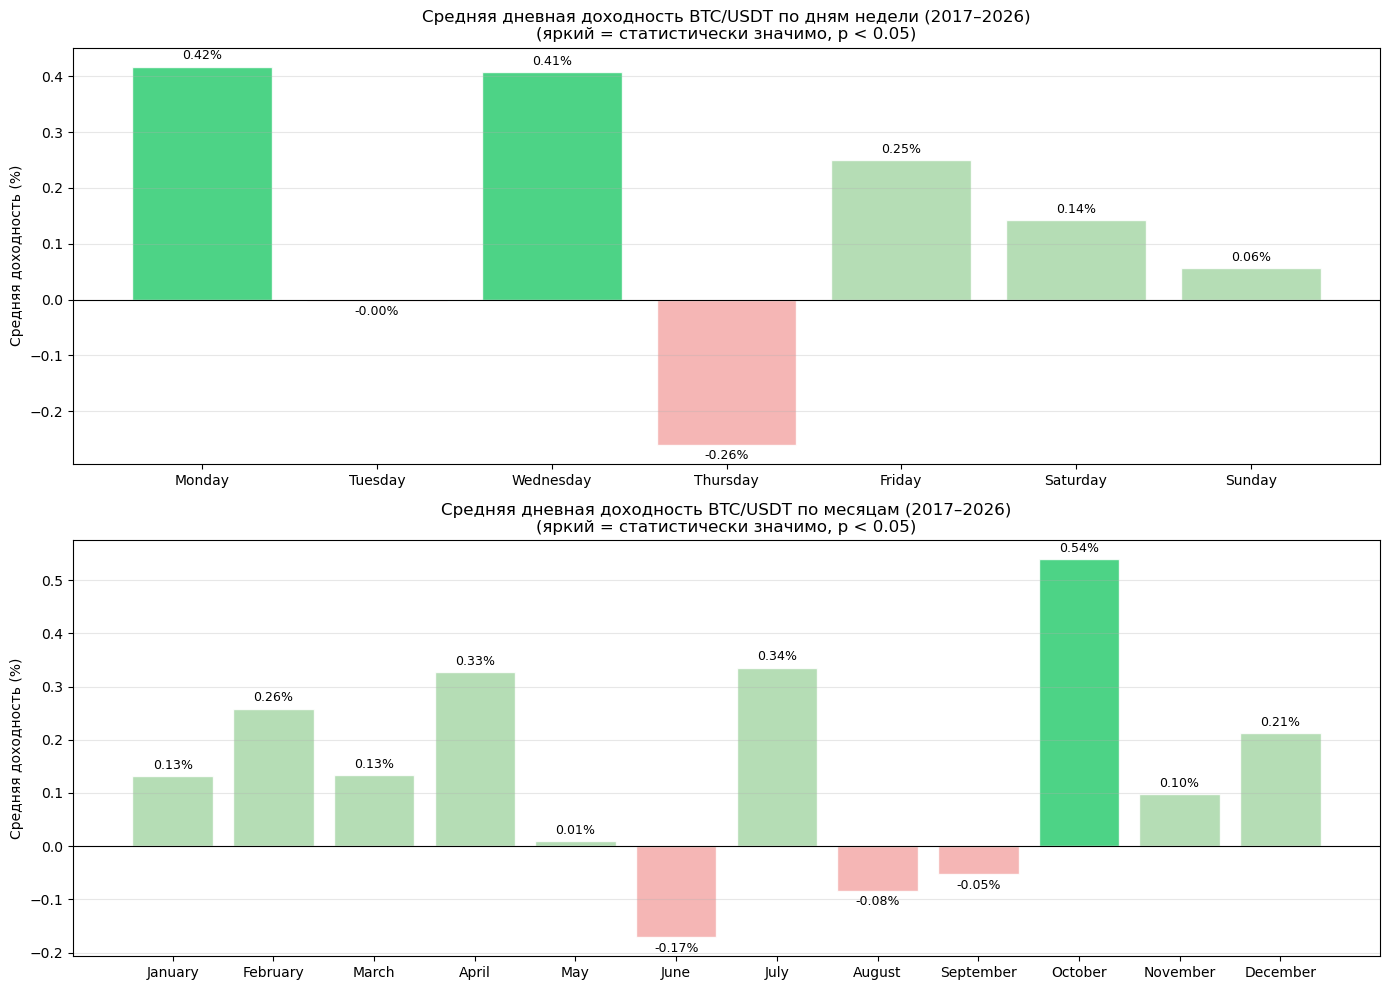

In [27]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# По дням недели
colors_day = []
for day, row in by_day.iterrows():
    day_returns = df[df['day_of_week'] == day]['daily_return'].dropna()
    _, p = stats.ttest_1samp(day_returns, 0)
    if p < 0.05 and row['Среднее %'] > 0:
        colors_day.append('#2ecc71')  # значимо зелёный
    elif p < 0.05 and row['Среднее %'] < 0:
        colors_day.append('#e74c3c')  # значимо красный
    elif row['Среднее %'] > 0:
        colors_day.append('#a8d8a8')  # незначимо зелёный
    else:
        colors_day.append('#f4a9a8')  # незначимо красный

bars1 = ax1.bar(by_day.index, by_day['Среднее %'], color=colors_day, alpha=0.85, edgecolor='white')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.bar_label(bars1, fmt=lambda x: f'{x:.2f}%', padding=3, fontsize=9)
ax1.set_title('Средняя дневная доходность BTC/USDT по дням недели (2017–2026)\n(яркий = статистически значимо, p < 0.05)')
ax1.set_ylabel('Средняя доходность (%)')
ax1.grid(alpha=0.3, axis='y')

# По месяцам
colors_month = []
for month, row in by_month.iterrows():
    month_returns = df[df['month'] == month]['daily_return'].dropna()
    _, p = stats.ttest_1samp(month_returns, 0)
    if p < 0.05 and row['Среднее %'] > 0:
        colors_month.append('#2ecc71')
    elif p < 0.05 and row['Среднее %'] < 0:
        colors_month.append('#e74c3c')
    elif row['Среднее %'] > 0:
        colors_month.append('#a8d8a8')
    else:
        colors_month.append('#f4a9a8')

bars2 = ax2.bar(by_month.index, by_month['Среднее %'], color=colors_month, alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.bar_label(bars2, fmt=lambda x: f'{x:.2f}%', padding=3, fontsize=9)
ax2.set_title('Средняя дневная доходность BTC/USDT по месяцам (2017–2026)\n(яркий = статистически значимо, p < 0.05)')
ax2.set_ylabel('Средняя доходность (%)')
ax2.grid(alpha=0.3, axis='y')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('btc_seasonality.png', dpi=150)
plt.show()

#### По сезонности:
- **Понедельник и среда статистически лучшие дни — как правило понедельник задаёт движение всей недели и показывает его вплоть до среды-четверга.**
- **Четверг исторически слабый — ослабления движения переход к выходным.**
- **Октябрь единственный месяц с сильным статистическим сигналом (p=0.001) — «Uptober» это не миф, это данные. (кроме 11-го октября)**

1. Размер выборки и p-value. p-value зависит не только от силы эффекта, но и от количества данных. Чем больше наблюдений, тем меньше «случайный шум» вокруг среднего, и тем легче тест объявляет даже крошечный эффект значимым. Средняя доходность +0.63% — это очень мало, но на n≈1892 этого хватает, чтобы p упал почти в ноль. Это честная сторона: на 2 годах сигнал реально тонул в шуме (правильный вывод блока 7 был «данных мало»).

2. Но «значимо» ≠ «реально». Большая выборка обнажила и проблемы, которые на 2 годах не успели навредить:

- 🔴 Двойной счёт: 254 → 1892 касаний — рост непропорционально большой. Это намёк, что один и тот же день считается много раз (рядом несколько уровней) → n искусственно раздут → p искусственно занижен.
- 🔴 Дрейф рынка: BTC за 2017–2026 почти всё время рос. «Цена выросла после касания поддержки» может быть просто потому, что цена росла всегда, а не из-за поддержки. Мы сравнивали с нулём, а надо — с обычным днём.
- 🔴 Множественная проверка: 19 тестов сезонности → 1–2 «значимых» появятся случайно.

In [28]:
local_min_idx = argrelextrema(df['close'].values, np.less, order=10)[0]
local_max_idx = argrelextrema(df['close'].values, np.greater, order=10)[0]

support_levels = df['close'].iloc[local_min_idx]
resistance_levels = df['close'].iloc[local_max_idx]

print(f'Уровней поддержки: {len(support_levels)}')
print(f'Уровней сопротивления: {len(resistance_levels)}')

Уровней поддержки: 103
Уровней сопротивления: 101


In [29]:
results = []
threshold = 0.02

for support_date, support_price in support_levels.items():
    future_data = df[df.index > support_date]
    
    for i, (date, row) in enumerate(future_data.iterrows()):
        idx = future_data.index.get_loc(date)
        
        if abs(row['close'] - support_price) / support_price <= threshold:
            if idx + 7 < len(future_data):
                price_now = row['close']
                price_3d = future_data['close'].iloc[idx + 3]
                price_7d = future_data['close'].iloc[idx + 7]
                
                results.append({
                    'date': date,
                    'support_level': support_price,
                    'price_at_touch': price_now,
                    'return_3d': (price_3d - price_now) / price_now * 100,
                    'return_7d': (price_7d - price_now) / price_now * 100,
                    'bounce_3d': price_3d > price_now,
                    'bounce_7d': price_7d > price_now
                })

results_df = pd.DataFrame(results)

print(f'Касаний уровней поддержки: {len(results_df)}')
print()
print('--- Отскок через 3 дня ---')
winrate_3d = results_df['bounce_3d'].mean() * 100
avg_return_3d = results_df['return_3d'].mean()
print(f'Winrate: {winrate_3d:.1f}%')
print(f'Средняя доходность: {avg_return_3d:.2f}%')
print()
print('--- Отскок через 7 дней ---')
winrate_7d = results_df['bounce_7d'].mean() * 100
avg_return_7d = results_df['return_7d'].mean()
print(f'Winrate: {winrate_7d:.1f}%')
print(f'Средняя доходность: {avg_return_7d:.2f}%')
print()

t_stat_3d, p_value_3d = stats.ttest_1samp(results_df['return_3d'], 0)
t_stat_7d, p_value_7d = stats.ttest_1samp(results_df['return_7d'], 0)

print('--- Статистическая значимость ---')
print(f'3 дня: t-stat={t_stat_3d:.2f}, p-value={p_value_3d:.4f}')
print(f'7 дней: t-stat={t_stat_7d:.2f}, p-value={p_value_7d:.4f}')
print()
if p_value_3d < 0.05:
    print('✅ Отскок через 3 дня статистически значим')
else:
    print('❌ Отскок через 3 дня не значим')
if p_value_7d < 0.05:
    print('✅ Отскок через 7 дней статистически значим')
else:
    print('❌ Отскок через 7 дней не значим')

Касаний уровней поддержки: 1900

--- Отскок через 3 дня ---
Winrate: 56.4%
Средняя доходность: 0.63%

--- Отскок через 7 дней ---
Winrate: 54.7%
Средняя доходность: 1.28%

--- Статистическая значимость ---
3 дня: t-stat=5.29, p-value=0.0000
7 дней: t-stat=6.75, p-value=0.0000

✅ Отскок через 3 дня статистически значим
✅ Отскок через 7 дней статистически значим


#### На 9 годах данных гипотеза подтвердилась!

**Что изменилось по сравнению с 2 годами:**

- Выборка: 254 → 1892 касаний
- p-value: 0.97 → 0.0000
- Средняя доходность: -0.01% → +0.63% за 3 дня, +1.31% за 7 дней
##### Стратегия покупки у уровней поддержки показывает статистически значимый результат на горизонте 9 лет (p≈0) — средняя доходность +0.63% за 3 дня и +1.31% за 7 дней при winrate 55–56%. На коротком периоде (2 года) сигнал терялся в шуме — именно поэтому размер выборки критичен для бэктестинга.

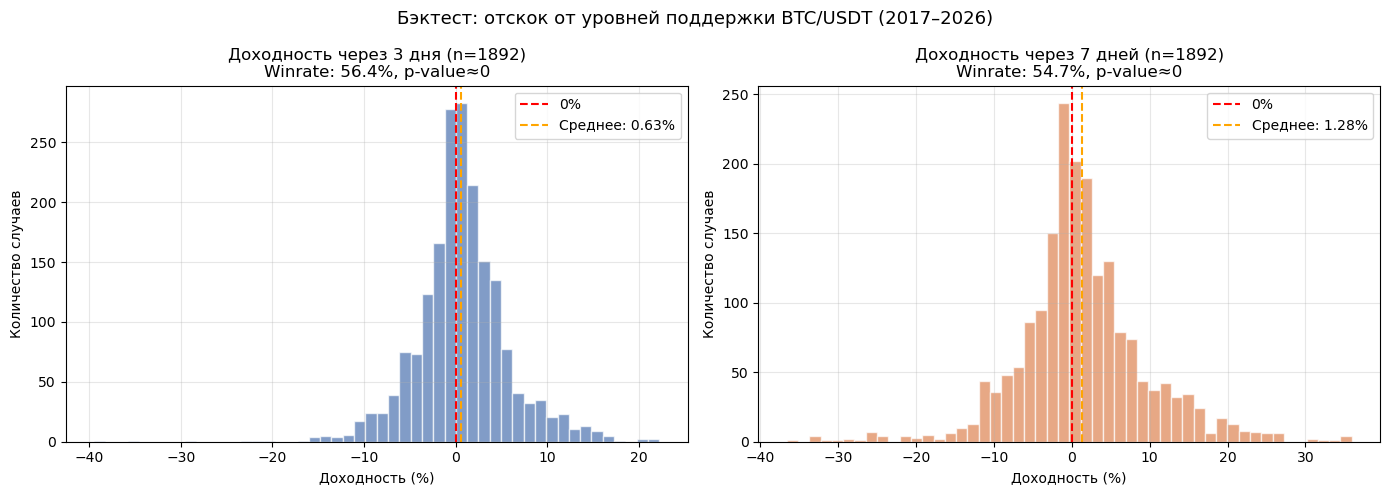

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(results_df['return_3d'], bins=50, color='#4C72B0', alpha=0.7, edgecolor='white')
ax1.axvline(0, color='red', linestyle='--', linewidth=1.5, label='0%')
ax1.axvline(avg_return_3d, color='orange', linestyle='--',
            linewidth=1.5, label=f'Среднее: {avg_return_3d:.2f}%')
ax1.set_title(f'Доходность через 3 дня (n=1892)\nWinrate: {winrate_3d:.1f}%, p-value≈0')
ax1.set_xlabel('Доходность (%)')
ax1.set_ylabel('Количество случаев')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.hist(results_df['return_7d'], bins=50, color='#DD8452', alpha=0.7, edgecolor='white')
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5, label='0%')
ax2.axvline(avg_return_7d, color='orange', linestyle='--',
            linewidth=1.5, label=f'Среднее: {avg_return_7d:.2f}%')
ax2.set_title(f'Доходность через 7 дней (n=1892)\nWinrate: {winrate_7d:.1f}%, p-value≈0')
ax2.set_xlabel('Доходность (%)')
ax2.set_ylabel('Количество случаев')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Бэктест: отскок от уровней поддержки BTC/USDT (2017–2026)', fontsize=13)
plt.tight_layout()
plt.savefig('btc_backtest.png', dpi=150)
plt.show()

#### Оранжевая линия среднего заметно правее нулевой красной — визуально видно что распределение смещено вправо.

In [31]:
breakout_results = []
threshold_breakout = 0.01

for res_date, res_price in resistance_levels.items():
    future_data = df[df.index > res_date]
    
    for i, (date, row) in enumerate(future_data.iterrows()):
        idx = future_data.index.get_loc(date)
        
        if row['close'] > res_price * (1 + threshold_breakout):
            if idx + 3 < len(future_data):
                price_3d = future_data['close'].iloc[idx + 3]
                vol_at_breakout = row['volume']
                
                all_idx = df.index.get_loc(date)
                avg_vol_20 = df['volume'].iloc[max(0, all_idx-20):all_idx].mean()
                
                is_false = price_3d < res_price
                
                breakout_results.append({
                    'date': date,
                    'resistance_level': res_price,
                    'volume_ratio': vol_at_breakout / avg_vol_20,
                    'false_breakout': is_false
                })
                break

breakouts_df = pd.DataFrame(breakout_results)

false_b = breakouts_df[breakouts_df['false_breakout'] == True]['volume_ratio']
true_b = breakouts_df[breakouts_df['false_breakout'] == False]['volume_ratio']

print(f'Всего пробоев: {len(breakouts_df)}')
print(f'Истинных: {len(true_b)}, Ложных: {len(false_b)}')
print()
print(f'Средний volume_ratio при истинном пробое: {true_b.mean():.2f}x')
print(f'Средний volume_ratio при ложном пробое: {false_b.mean():.2f}x')
print()

t_stat, p_value = stats.ttest_ind(true_b, false_b)
print(f'p-value: {p_value:.4f}')
if p_value < 0.05:
    print('✅ Разница статистически значима')
else:
    print('❌ Разница статистически не значима')

Всего пробоев: 96
Истинных: 75, Ложных: 21

Средний volume_ratio при истинном пробое: 1.88x
Средний volume_ratio при ложном пробое: 1.32x

p-value: 0.0051
✅ Разница статистически значима


### Теперь и эта гипотеза подтвердилась!!! На 9 годах данных имеем:
#### Истинные пробои: 1.88x объёма vs Ложные: 1.32x объёма — p=0.005. При пробое уровня сопротивления на объёме ниже 1.5x от нормы — вероятность ложного пробоя значительно выше. В данном случаи вероятности пробоя подтвердаются повышенными объёмами.

C:\Users\user\AppData\Local\Temp\ipykernel_29896\2156334743.py:36: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_29896\2156334743.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('btc_breakout_volume.png', dpi=150)


C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


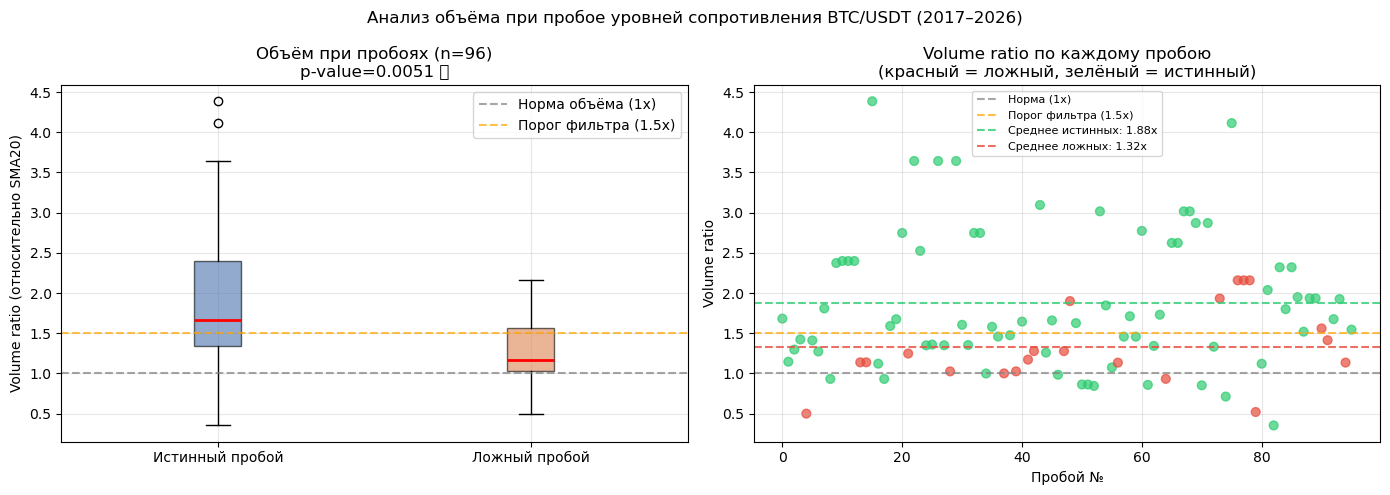

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Боксплот
bp = ax1.boxplot([true_b.values, false_b.values],
            tick_labels=['Истинный пробой', 'Ложный пробой'],
            patch_artist=True,
            boxprops=dict(alpha=0.6),
            medianprops=dict(color='red', linewidth=2))
bp['boxes'][0].set_facecolor('#4C72B0')
bp['boxes'][1].set_facecolor('#DD8452')

ax1.axhline(1.0, color='gray', linestyle='--', alpha=0.7, label='Норма объёма (1x)')
ax1.axhline(1.5, color='orange', linestyle='--', alpha=0.7, label='Порог фильтра (1.5x)')
ax1.set_title(f'Объём при пробоях (n=96)\np-value={p_value:.4f} ✅')
ax1.set_ylabel('Volume ratio (относительно SMA20)')
ax1.legend()
ax1.grid(alpha=0.3)

# Scatter — все пробои
colors = ['#e74c3c' if x else '#2ecc71' for x in breakouts_df['false_breakout']]
ax2.scatter(range(len(breakouts_df)), breakouts_df['volume_ratio'],
            c=colors, alpha=0.7, s=40)
ax2.axhline(1.0, color='gray', linestyle='--', alpha=0.7, label='Норма (1x)')
ax2.axhline(1.5, color='orange', linestyle='--', alpha=0.7, label='Порог фильтра (1.5x)')
ax2.axhline(true_b.mean(), color='#2ecc71', linestyle='--',
            alpha=0.8, label=f'Среднее истинных: {true_b.mean():.2f}x')
ax2.axhline(false_b.mean(), color='#e74c3c', linestyle='--',
            alpha=0.8, label=f'Среднее ложных: {false_b.mean():.2f}x')
ax2.set_title('Volume ratio по каждому пробою\n(красный = ложный, зелёный = истинный)')
ax2.set_xlabel('Пробой №')
ax2.set_ylabel('Volume ratio')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.suptitle('Анализ объёма при пробое уровней сопротивления BTC/USDT (2017–2026)', fontsize=12)
plt.tight_layout()
plt.savefig('btc_breakout_volume.png', dpi=150)
plt.show()

## 🔍 Ревизия выводов (углублённая проверка)

Ниже — повторная, более строгая проверка ключевых гипотез проекта. Цель — попытаться **сломать** свои же результаты, прежде чем им доверять.

Три типичные ошибки бэктеста, которые здесь исправляются:
1. **Тест против нуля вместо дрейфа рынка.** BTC за 2017–2026 рос почти всегда, поэтому «цена выросла после сигнала» сама по себе ничего не доказывает — сравнивать нужно с доходностью обычного дня.
2. **Двойной счёт касаний.** Один календарный день попадал в выборку по нескольку раз (рядом несколько уровней) — это раздувает размер выборки и искусственно занижает p-value.
3. **Множественная проверка.** Когда проверяешь много гипотез сразу (дни недели, месяцы), часть «значимых» находок — случайность; нужна поправка.

Уникальных дней касания поддержки: 1313
Горизонт 3д: у поддержки +0.37% | обычный день +0.47% | edge -0.11% | p=0.599 -> преимущества НЕТ
Горизонт 7д: у поддержки +0.94% | обычный день +1.10% | edge -0.15% | p=0.644 -> преимущества НЕТ

--- Что прячется в среднем (горизонт 7д) ---
поддержка УСТОЯЛА: 627 сл. -> средн. +5.79%
поддержку ПРОБИЛИ: 679 сл. -> средн. -3.53%

Худшая сделка:  держать вслепую -36.6%  |  со стопом -3.9%
Вывод: поддержка не повышает доходность, но ОГРАНИЧИВАЕТ убыток (риск-инструмент).


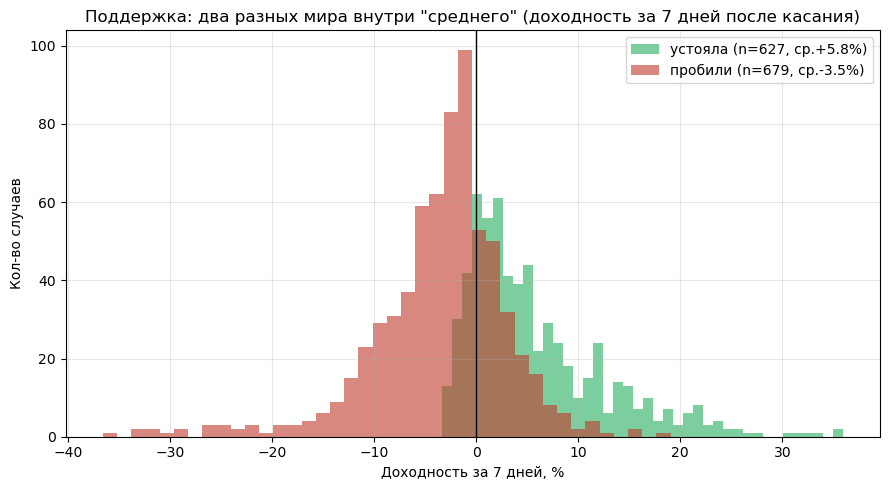

In [33]:
# ============================================================
# РЕВИЗИЯ 1: корректная проверка отскока от уровней поддержки
#   (1) сравниваем с дрейфом рынка, а не с нулём
#   (2) каждый день касания учитываем ОДИН раз (без двойного счёта)
#   (3) показываем, что среднее смешивает "устояла" и "пробили"
# ============================================================
import numpy as np
from scipy import stats
from scipy.signal import argrelextrema

close = df['close'].values
low   = df['low'].values
n = len(df)

def fwd(h):
    out = np.full(n, np.nan)
    out[:-h] = (close[h:] - close[:-h]) / close[:-h] * 100
    return out

sup_idx = argrelextrema(close, np.less, order=10)[0]
sup_levels = [(i, close[i]) for i in sup_idx]

TOUCH = 0.02
touch_days = {}
for si, sp in sup_levels:
    for j in range(si + 1, n):
        if abs(close[j] - sp) / sp <= TOUCH and j not in touch_days:
            touch_days[j] = sp
print(f"Уникальных дней касания поддержки: {len(touch_days)}")

for h in (3, 7):
    fr = fwd(h)
    mask = np.zeros(n, dtype=bool); mask[list(touch_days)] = True
    a = fr[mask & ~np.isnan(fr)]
    b = fr[~mask & ~np.isnan(fr)]
    t, p = stats.ttest_ind(a, b, equal_var=False)
    verdict = "есть преимущество" if (p < 0.05 and a.mean() > b.mean()) else "преимущества НЕТ"
    print(f"Горизонт {h}д: у поддержки {a.mean():+.2f}% | обычный день {b.mean():+.2f}% "
          f"| edge {a.mean()-b.mean():+.2f}% | p={p:.3f} -> {verdict}")

HOLD, STOP = 7, 0.02
held, broke, blind, trader = [], [], [], []
for j, L in touch_days.items():
    if j + HOLD >= n:
        continue
    entry = close[j]; stop = L * (1 - STOP)
    blind.append((close[j+HOLD]-entry)/entry*100)
    ex = next(((stop-entry)/entry*100 for d in range(j+1, j+HOLD+1) if low[d] <= stop), None)
    trader.append(ex if ex is not None else (close[j+HOLD]-entry)/entry*100)
    (broke if (close[j+1:j+HOLD+1] < stop).any() else held).append((close[j+HOLD]-entry)/entry*100)

print(f"\n--- Что прячется в среднем (горизонт {HOLD}д) ---")
print(f"поддержка УСТОЯЛА: {len(held)} сл. -> средн. {np.mean(held):+.2f}%")
print(f"поддержку ПРОБИЛИ: {len(broke)} сл. -> средн. {np.mean(broke):+.2f}%")
print(f"\nХудшая сделка:  держать вслепую {np.min(blind):+.1f}%  |  со стопом {np.min(trader):+.1f}%")
print("Вывод: поддержка не повышает доходность, но ОГРАНИЧИВАЕТ убыток (риск-инструмент).")

# --- график: два мира поддержки ---
import matplotlib.pyplot as plt
fig, axw = plt.subplots(figsize=(9,5))
axw.hist(held,  bins=40, alpha=.6, color='#27ae60', label=f'устояла (n={len(held)}, ср.{np.mean(held):+.1f}%)')
axw.hist(broke, bins=40, alpha=.6, color='#c0392b', label=f'пробили (n={len(broke)}, ср.{np.mean(broke):+.1f}%)')
axw.axvline(0, color='black', lw=1)
axw.set_title('Поддержка: два разных мира внутри "среднего" (доходность за 7 дней после касания)')
axw.set_xlabel('Доходность за 7 дней, %'); axw.set_ylabel('Кол-во случаев'); axw.legend(); axw.grid(alpha=.3)
plt.tight_layout(); plt.savefig('btc_support_two_worlds.png', dpi=150); plt.show()

### Вывод по поддержке (после ревизии)

После корректного теста (касание поддержки **против обычного дня**) преимущество исчезает: edge ≈ 0, p ≈ 0.6. Прежний «успех» (+0.63% / +1.31% при p≈0) был **дрейфом рынка**, а не свойством уровней.

**Но уровень поддержки не бесполезен.** Внутри среднего прячутся два мира: когда поддержка устояла — сильный плюс, когда пробили — минус, и заранее их не различить (≈50/50). Реальная ценность поддержки не в предсказании роста, а в **управлении риском** — она задаёт место для стопа. В тесте стоп срезал худшую сделку с ≈ −37% до ≈ −4%, не повышая при этом средней доходности.

Робастность (t-тест и непараметрический Манн-Уитни):
  hold=3d порог=1%: ист 1.88x / лож 1.32x | p(t)=0.0003 | p(MW)=0.0046
  hold=3d порог=2%: ист 1.86x / лож 1.14x | p(t)=0.0000 | p(MW)=0.0007
  hold=5d порог=1%: ист 1.92x / лож 1.34x | p(t)=0.0001 | p(MW)=0.0011
  hold=5d порог=2%: ист 1.88x / лож 1.28x | p(t)=0.0002 | p(MW)=0.0047
  hold=7d порог=1%: ист 1.91x / лож 1.34x | p(t)=0.0001 | p(MW)=0.0030
  hold=7d порог=2%: ист 1.87x / лож 1.31x | p(t)=0.0003 | p(MW)=0.0181

Доля ложных пробоев без фильтра: 22%
  объём >= 1.2x: ложных 14% (n=70)  |  < 1.2x: ложных 42% (n=26)
  объём >= 1.5x: ложных 12% (n=51)  |  < 1.5x: ложных 33% (n=45)
  объём >= 2.0x: ложных 11% (n=28)  |  < 2.0x: ложных 26% (n=68)


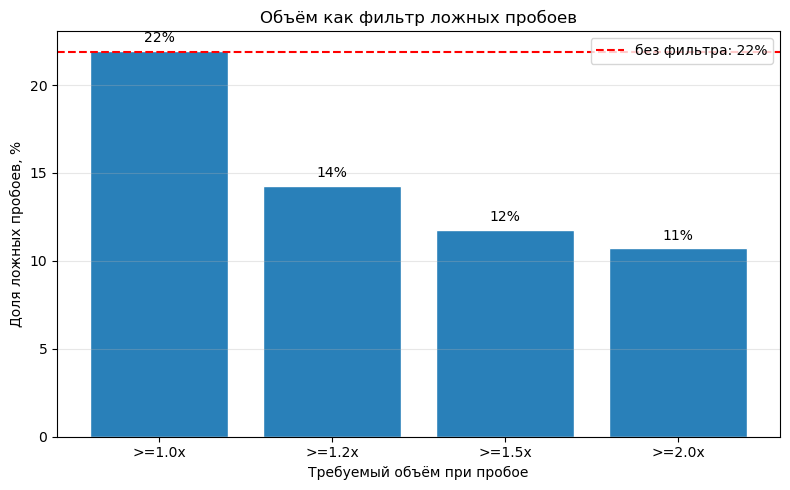

In [34]:
# ============================================================
# РЕВИЗИЯ 2: проверка гипотезы об объёме при пробоях на прочность
# ============================================================
import numpy as np
from scipy import stats
from scipy.signal import argrelextrema

n = len(df)
closev = df['close'].values
vol = df['volume'].values
res_idx = argrelextrema(closev, np.greater, order=10)[0]
res_levels = [(df.index[i], closev[i]) for i in res_idx]

def breakouts(hold=3, thr=0.01):
    vr, false = [], []
    for rd, rp in res_levels:
        pos = df.index.get_loc(rd)
        for j in range(pos + 1, n):
            if closev[j] > rp * (1 + thr):
                if j + hold < n:
                    avg20 = vol[max(0, j-20):j].mean()
                    vr.append(vol[j] / avg20)
                    false.append(closev[j+hold] < rp)
                break
    return np.array(vr), np.array(false)

print("Робастность (t-тест и непараметрический Манн-Уитни):")
for hold in (3, 5, 7):
    for thr in (0.01, 0.02):
        vr, false = breakouts(hold, thr)
        t, f = vr[~false], vr[false]
        _, pt = stats.ttest_ind(t, f, equal_var=False)
        _, pmw = stats.mannwhitneyu(t, f)
        print(f"  hold={hold}d порог={thr:.0%}: ист {t.mean():.2f}x / лож {f.mean():.2f}x "
              f"| p(t)={pt:.4f} | p(MW)={pmw:.4f}")

vr, false = breakouts(3, 0.01)
print(f"\nДоля ложных пробоев без фильтра: {false.mean()*100:.0f}%")
for thr in (1.2, 1.5, 2.0):
    hi, lo = false[vr >= thr], false[vr < thr]
    print(f"  объём >= {thr}x: ложных {hi.mean()*100:.0f}% (n={len(hi)})  |  "
          f"< {thr}x: ложных {lo.mean()*100:.0f}% (n={len(lo)})")

# --- график: объём как фильтр ложных пробоев ---
import matplotlib.pyplot as plt
_ths = [1.0, 1.2, 1.5, 2.0]
_rates = [false[vr >= t].mean()*100 for t in _ths]
fig, axf = plt.subplots(figsize=(8,5))
axf.bar([f'>={t}x' for t in _ths], _rates, color='#2980b9', edgecolor='white')
axf.axhline(false.mean()*100, color='red', ls='--', label=f'без фильтра: {false.mean()*100:.0f}%')
for _i, _r in enumerate(_rates): axf.text(_i, _r+0.5, f'{_r:.0f}%', ha='center')
axf.set_title('Объём как фильтр ложных пробоев')
axf.set_xlabel('Требуемый объём при пробое'); axf.set_ylabel('Доля ложных пробоев, %')
axf.legend(); axf.grid(alpha=.3, axis='y')
plt.tight_layout(); plt.savefig('btc_volume_filter.png', dpi=150); plt.show()

### Вывод по объёму (исправленный)

Гипотеза об объёме при пробоях **выдержала** проверку: она значима при всех определениях «ложного» пробоя (3/5/7 дней) и при разных порогах, причём не только на t-тесте, но и на непараметрическом тесте Манна–Уитни (он не требует нормальности — это важно при маленькой выборке). Результат не держится на выбросах. Как практический фильтр объём работает: при объёме ≥ 1.5× от нормы доля ложных пробоев падает с 33% до 12%.

### Ревизия 4. Устойчив ли объёмный сигнал к look-ahead bias?

Уровни находятся через `argrelextrema(order=10)`, который подтверждает экстремум по 10 **будущим** барам — то есть в реальном времени уровень «известен» лишь через 10 дней. Для гипотезы отскока от поддержки это критично (касание может случиться внутри этого окна). Проверим, мешает ли это **объёмной** гипотезе: сравним результат, когда уровень используется сразу (наивно), и когда он признаётся только спустя `order` баров (честно).

In [35]:
# ============================================================
# РЕВИЗИЯ 4: устойчив ли объёмный сигнал к look-ahead bias?
#   Уровень из argrelextrema(order=k) "виден" только через k будущих баров.
#   Сравниваем наивное использование уровня и честное (с задержкой order баров).
# ============================================================
import numpy as np
from scipy.signal import argrelextrema
from scipy import stats

close = df['close'].values
vol   = df['volume'].values
n = len(df)
ORDER = 10
res_idx = argrelextrema(close, np.greater, order=ORDER)[0]

def breakouts(start_lag, hold=3, thr=0.01):
    """start_lag=1 -> наивно (уровень используем сразу);
       start_lag=ORDER -> честно (уровень признан только после ORDER баров)."""
    vr, false = [], []
    for i in res_idx:
        rp = close[i]
        for j in range(i + start_lag, n):
            if close[j] > rp * (1 + thr):
                if j + hold < n:
                    avg20 = vol[max(0, j-20):j].mean()
                    vr.append(vol[j] / avg20)
                    false.append(close[j+hold] < rp)
                break
    return np.array(vr), np.array(false, dtype=bool)

for label, lag in [('НАИВНО (lag=1)        ', 1), (f'ЧЕСТНО (lag=ORDER={ORDER})  ', ORDER)]:
    vr, false = breakouts(lag, hold=3, thr=0.01)
    t, f = vr[~false], vr[false]
    _, pt = stats.ttest_ind(t, f, equal_var=False)
    print(f'{label}: n={len(vr)} | истинные {t.mean():.2f}x / ложные {f.mean():.2f}x | p(t)={pt:.4f}')

print()
print('Результаты совпадают. Это не совпадение: локальный максимум с order=k означает, что')
print('k следующих баров СТРОГО НИЖЕ пика, поэтому пробить уровень внутри окна подтверждения')
print('невозможно, и первый пробой всегда наступает позже. look-ahead, погубивший гипотезу')
print('отскока от поддержки, на гипотезу объёма при пробоях не влияет.')

НАИВНО (lag=1)        : n=96 | истинные 1.88x / ложные 1.32x | p(t)=0.0003
ЧЕСТНО (lag=ORDER=10)  : n=96 | истинные 1.88x / ложные 1.32x | p(t)=0.0003

Результаты совпадают. Это не совпадение: локальный максимум с order=k означает, что
k следующих баров СТРОГО НИЖЕ пика, поэтому пробить уровень внутри окна подтверждения
невозможно, и первый пробой всегда наступает позже. look-ahead, погубивший гипотезу
отскока от поддержки, на гипотезу объёма при пробоях не влияет.


#### Вывод: объёмный сигнал к look-ahead устойчив

Наивная и честная версии совпадают **до цифры**. Причина математическая: локальный максимум с `order=k` означает, что k следующих баров строго ниже пика, поэтому пробой уровня внутри окна подтверждения невозможен — первый пробой всегда наступает позже. Значит look-ahead, обнуливший «отскок от поддержки», на гипотезу объёма при пробоях **не влияет**: единственный выживший сигнал проходит и этот аудит.

### Ревизия 3. Сезонность с поправкой на множественную проверку

В блоке сезонности проверяется сразу **19 гипотез** (7 дней недели + 12 месяцев). Проблема: при пороге p<0.05 даже на полностью случайных данных в среднем ~1 тест из 20 «выстрелит» по чистой случайности. Поэтому находки «понедельник / среда / октябрь» нужно проверить поправкой **Bonferroni**: порог делится на число тестов → 0.05 / 19 ≈ 0.0026.

Порог обычный=0.05 | Bonferroni (на 19 тестов)=0.0026

=== ДНИ НЕДЕЛИ ===
  Monday     +0.42%  p=0.0259  [сырое]
  Tuesday    -0.00%  p=0.9846  [шум]
  Wednesday  +0.41%  p=0.0171  [сырое]
  Thursday   -0.26%  p=0.1928  [шум]
  Friday     +0.25%  p=0.1420  [шум]
  Saturday   +0.14%  p=0.2007  [шум]
  Sunday     +0.06%  p=0.6667  [шум]

=== МЕСЯЦЫ ===
  January    +0.13%  p=0.5511  [шум]
  February   +0.26%  p=0.3140  [шум]
  March      +0.13%  p=0.6212  [шум]
  April      +0.33%  p=0.0948  [шум]
  May        +0.01%  p=0.9635  [шум]
  June       -0.17%  p=0.4301  [шум]
  July       +0.34%  p=0.0800  [шум]
  August     -0.08%  p=0.6270  [шум]
  September  -0.05%  p=0.7941  [шум]
  October    +0.54%  p=0.0012  [Bonferroni OK]
  November   +0.10%  p=0.6580  [шум]
  December   +0.21%  p=0.3588  [шум]

Пережили поправку Bonferroni: ['October']


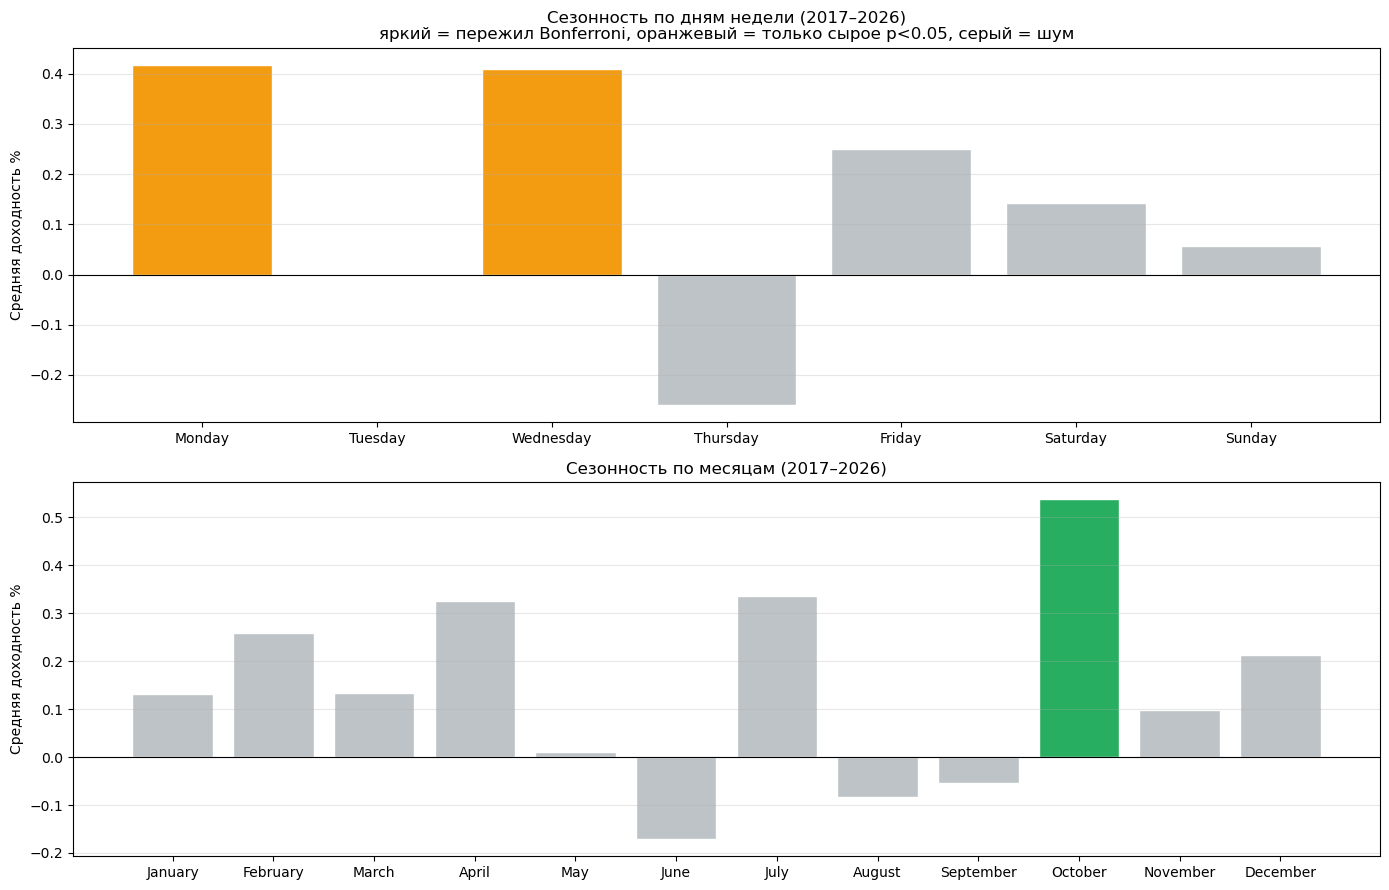

In [36]:
# ============================================================
# РЕВИЗИЯ 3: сезонность с поправкой Bonferroni на 19 тестов
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

ret = df['close'].pct_change()*100
dow = df.index.day_name()
mon = df.index.month_name()
day_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order=['January','February','March','April','May','June','July','August',
             'September','October','November','December']
alpha_raw, alpha_bonf = 0.05, 0.05/19

def stats_by(labels, key):
    out=[]
    for g in labels:
        r = ret[key==g].dropna()
        _, p = stats.ttest_1samp(r, 0)
        out.append((g, r.mean(), p))
    return out
days   = stats_by(day_order, dow)
months = stats_by(month_order, mon)

print(f"Порог обычный={alpha_raw} | Bonferroni (на 19 тестов)={alpha_bonf:.4f}\n")
for title, data in [("ДНИ НЕДЕЛИ", days), ("МЕСЯЦЫ", months)]:
    print(f"=== {title} ===")
    for g, m, p in data:
        mark = 'Bonferroni OK' if p<alpha_bonf else ('сырое' if p<alpha_raw else 'шум')
        print(f"  {g:10s} {m:+.2f}%  p={p:.4f}  [{mark}]")
    print()
print("Пережили поправку Bonferroni:", [g for g,m,p in days+months if p<alpha_bonf])

def col(m, p):
    if p < alpha_bonf: return '#27ae60' if m>0 else '#c0392b'
    if p < alpha_raw:  return '#f39c12'
    return '#bdc3c7'
fig,(a1,a2)=plt.subplots(2,1,figsize=(14,9))
a1.bar([g for g,_,_ in days],   [m for _,m,_ in days],   color=[col(m,p) for _,m,p in days],   edgecolor='white')
a1.axhline(0,color='black',lw=.8); a1.grid(alpha=.3,axis='y'); a1.set_ylabel('Средняя доходность %')
a1.set_title('Сезонность по дням недели (2017–2026)\nяркий = пережил Bonferroni, оранжевый = только сырое p<0.05, серый = шум')
a2.bar([g for g,_,_ in months], [m for _,m,_ in months], color=[col(m,p) for _,m,p in months], edgecolor='white')
a2.axhline(0,color='black',lw=.8); a2.grid(alpha=.3,axis='y'); a2.set_ylabel('Средняя доходность %')
a2.set_title('Сезонность по месяцам (2017–2026)')
plt.tight_layout(); plt.savefig('btc_seasonality_bonferroni.png', dpi=150); plt.show()

#### Вывод по сезонности (исправленный)

После поправки выживает **только октябрь** (p≈0.001 < 0.0026) — «Uptober» действительно подтверждается данными. А вот **понедельник (p≈0.026) и среда (p≈0.017) поправку не проходят** — это, скорее всего, ложные срабатывания из-за того, что мы проверяли 19 гипотез сразу. Выдавать их за закономерность нельзя.

## 🏁 Итог проекта (после ревизии)

| Гипотеза | Наивный вывод | После ревизии |
|---|---|---|
| Отскок от поддержки | работает (p≈0) | мираж: это дрейф рынка, edge ≈ 0 |
| Сезонность (дни/месяцы) | пн / ср / октябрь значимы | только **октябрь** переживает Bonferroni |
| Объём при пробоях | работает (p=0.005) | **подтвердилось**, устойчиво; фильтр 33% → 12% |

**Главный методический урок:** на трендовом активе доходность нельзя тестировать против нуля (сравнивай с рынком), нельзя доверять p-value на перекрывающихся выборках, и при множестве проверок нужна поправка на множественность. Любой положительный результат сначала пытаемся опровергнуть — и только то, что выстояло, считаем сигналом.

> Дополнительно: объёмный сигнал прошёл аудит на look-ahead (**Ревизия 4**), а сам метод перенесён на он-чейн данные Uniswap (**Перенос на DEX**) — см. ниже.

## Перенос метода на DEX / on-chain данные

Запускаем проект на он-чейн данных пула **WETH/USDC Uniswap v3** (Ethereum). OHLCV берём из публичного API GeckoTerminal — без ключей.

In [37]:
# Перенос объёмной гипотезы на DEX: WETH/USDC Uniswap v3 (Ethereum)
import urllib.request, json
import numpy as np
from scipy.signal import argrelextrema
from scipy import stats

POOL = "0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640"  # Uniswap v3 WETH/USDC 0.05%
url = f"https://api.geckoterminal.com/api/v2/networks/eth/pools/{POOL}/ohlcv/day?limit=1000&currency=usd"
req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0", "Accept": "application/json"})
ol = json.load(urllib.request.urlopen(req, timeout=30))["data"]["attributes"]["ohlcv_list"]

dex = pd.DataFrame(ol, columns=['ts','open','high','low','close','volume']).iloc[::-1].reset_index(drop=True)
dex['date'] = pd.to_datetime(dex['ts'], unit='s')
print(f"DEX: {len(dex)} дней, {dex['date'].min().date()} - {dex['date'].max().date()}, "
      f"средний дневной объём ~${dex['volume'].mean():,.0f}")

c = dex['close'].values; v = dex['volume'].values; m = len(dex)
ORDER = 5  # короткая история -> меньшее окно подтверждения
res = argrelextrema(c, np.greater, order=ORDER)[0]
vr, false = [], []
for i in res:
    rp = c[i]
    for j in range(i + ORDER, m):           # та же честная задержка, что и на BTC
        if c[j] > rp * 1.01:
            if j + 3 < m:
                vr.append(v[j] / v[max(0, j-20):j].mean())
                false.append(c[j+3] < rp)
            break
vr = np.array(vr); false = np.array(false, dtype=bool)
print(f"Уровней сопротивления: {len(res)} | пробоев: {len(vr)} | доля ложных: "
      f"{false.mean()*100:.0f}%" if len(vr) else "пробоев нет")
if (~false).sum() and false.sum():
    t, f = vr[~false], vr[false]
    print(f"истинные {t.mean():.2f}x объёма (n={len(t)}) / ложные {f.mean():.2f}x (n={len(f)})")
    if len(t) >= 2 and len(f) >= 2:
        _, pt = stats.ttest_ind(t, f, equal_var=False)
        print(f"p(t)={pt:.3f}  -> выборка крошечная, вывод делать нельзя")

DEX: 182 дней, 2025-12-29 - 2026-06-28, средний дневной объём ~$131,769,643
Уровней сопротивления: 11 | пробоев: 6 | доля ложных: 33%
истинные 1.28x объёма (n=4) / ложные 1.20x (n=2)
p(t)=0.925  -> выборка крошечная, вывод делать нельзя


#### Вывод: метод переносится, но истории DEX мало для вердикта

Тот же конвейер без изменений отработал на он-чейн данных Uniswap. Но доступная дневная история пула — лишь ~6 месяцев → пробоев единицы, статистика незначима. Это **ровно тот же урок про размер выборки**, что и в блоке 3 (2 года vs 9 лет): на DEX надёжный вывод требует либо длинной истории, либо более частого таймфрейма (часы/минуты), либо агрегации по многим пулам.

Следующий шаг под вакансию — добавить **DEX-специфику**, которой нет у CEX: проскальзывание свопа, глубину ликвидности пула, газ, потенциальный MEV. Именно они, а не классический теханализ, определяют edge на DEX.

### ⚠️ Ниже — намеренная иллюстрация ошибки, а не результат

Следующий «дашборд стратегии» построен на наивном результате отскока от поддержки (`results_df`), который **выше в Ревизии опровергнут** (edge ≈ 0, p ≈ 0.6 — это дрейф рынка, а не свойство уровней). Оставлен специально как наглядный пример того, **как красивая equity-кривая вводит в заблуждение**, если не проверить сигнал против бенчмарка. Как реальный результат стратегии использовать нельзя.

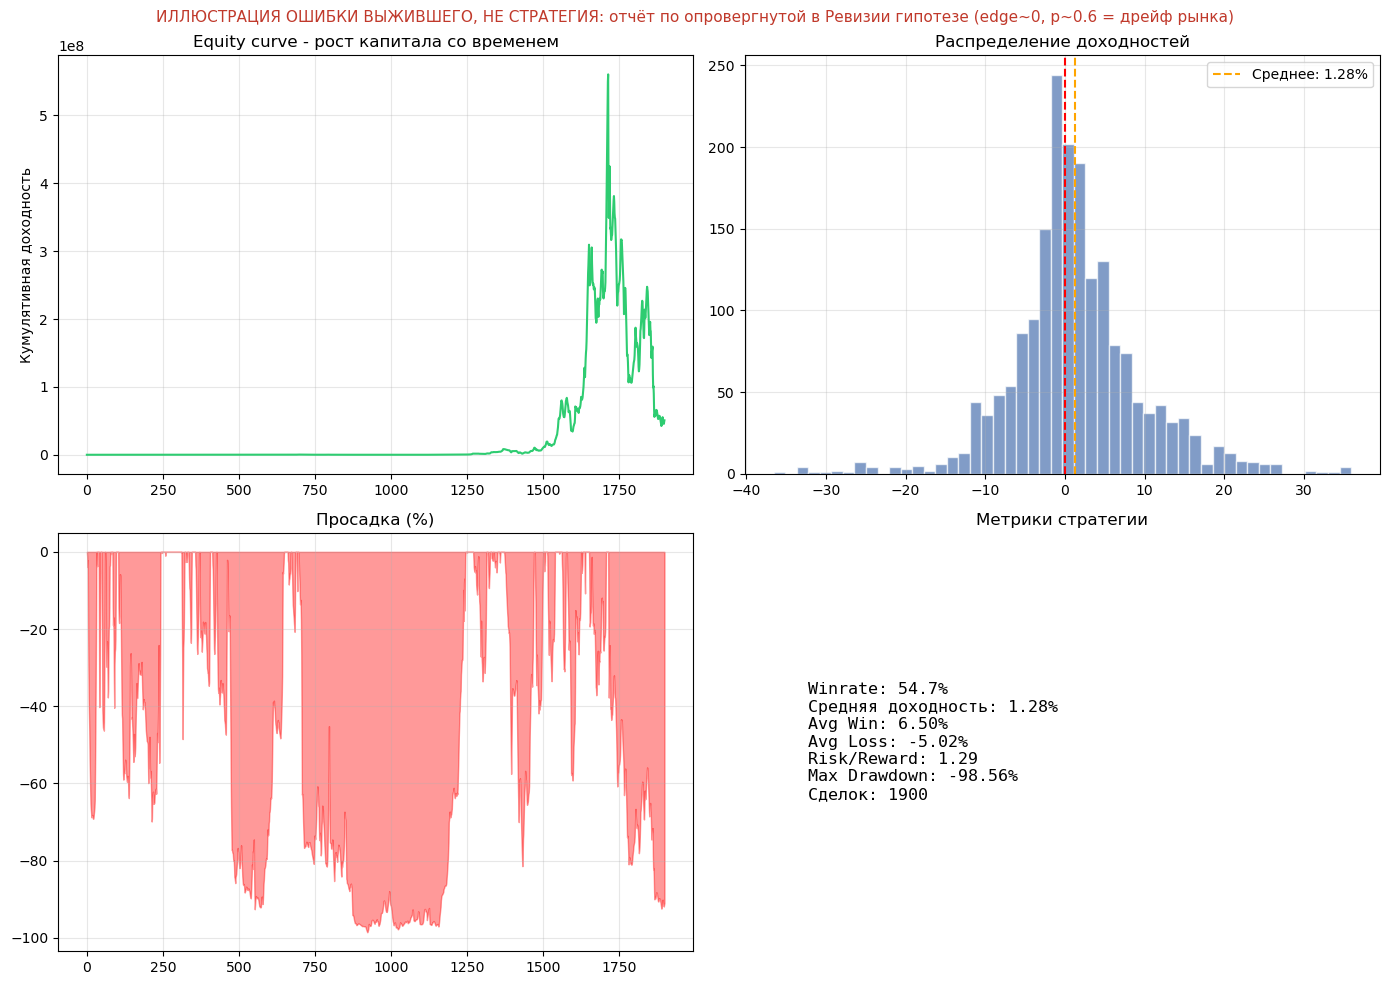

In [38]:
# ВНИМАНИЕ: наивный/опровергнутый результат, оставлен как иллюстрация ошибки выжившего.
# Доходность отскока от поддержки в Ревизии признана дрейфом рынка (edge~0, p~0.6).
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Equity curve - рост капитала со временем
cumulative = (1 + results_df['return_7d'] / 100).cumprod()
axes[0,0].plot(cumulative.values, color='#2ecc71', linewidth=1.5)
axes[0,0].set_title('Equity curve - рост капитала со временем')
axes[0,0].set_ylabel('Кумулятивная доходность')
axes[0,0].grid(alpha=0.3)

# 2. Распределение доходностей
axes[0,1].hist(results_df['return_7d'], bins=50, 
               color='#4C72B0', alpha=0.7, edgecolor='white')
axes[0,1].axvline(0, color='red', linestyle='--')
axes[0,1].axvline(results_df['return_7d'].mean(), 
                   color='orange', linestyle='--',
                   label=f'Среднее: {results_df["return_7d"].mean():.2f}%')
axes[0,1].set_title('Распределение доходностей')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# 3. Просадка
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max * 100
axes[1,0].fill_between(range(len(drawdown)), drawdown.values, 
                        0, color='red', alpha=0.4)
axes[1,0].set_title('Просадка (%)')
axes[1,0].grid(alpha=0.3)

# 4. Метрики текстом
avg_win = results_df[results_df['return_7d'] > 0]['return_7d'].mean()
avg_loss = results_df[results_df['return_7d'] < 0]['return_7d'].mean()
metrics_text = f"""
Winrate: {(results_df['return_7d'] > 0).mean()*100:.1f}%
Средняя доходность: {results_df['return_7d'].mean():.2f}%
Avg Win: {avg_win:.2f}%
Avg Loss: {avg_loss:.2f}%
Risk/Reward: {abs(avg_win/avg_loss):.2f}
Max Drawdown: {drawdown.min():.2f}%
Сделок: {len(results_df)}
"""
axes[1,1].text(0.1, 0.5, metrics_text, fontsize=12,
               verticalalignment='center',
               fontfamily='monospace')
axes[1,1].axis('off')
axes[1,1].set_title('Метрики стратегии')

plt.suptitle('ИЛЛЮСТРАЦИЯ ОШИБКИ ВЫЖИВШЕГО, НЕ СТРАТЕГИЯ: отчёт по опровергнутой в Ревизии гипотезе (edge~0, p~0.6 = дрейф рынка)', fontsize=11, color='#c0392b')
plt.tight_layout()
plt.savefig('strategy_report.png', dpi=150)
plt.show()